
# Final Journal Notebook V3.1 — FINAL LOCKED
## Robust Polar Denoising and Decoding Across Heterogeneous Channels

### Final comparison

\[
\text{SC}
\rightarrow
\text{ML}
\rightarrow
\text{PNND}
\rightarrow
\text{RNND-Zhu}
\rightarrow
\text{CNN-RNND}
\rightarrow
\boxed{\text{Proposed CA-CNN-RNND}}
\]

The proposed model **does not contain the reliability gate**.  
The decisive 8,000-epoch pilot showed that the gate produced only a marginal gain, so the final architecture is the simpler **Channel-Aware CNN-RNND**.

### Three final experiments

1. **Mixed-channel robustness**
   - Train: AWGN + Rayleigh + Rician-like LOS + Impulsive
   - Test each channel separately

2. **Matched-channel performance**
   - Train and test on the same channel

3. **Unseen-channel generalization**
   - Default:
     - Train: AWGN + Rayleigh + Rician-like LOS
     - Test: unseen Impulsive noise

### Journal protocol

- Polar code: \((16,8)\)
- BPSK
- 5 independent repeats
- \(E_b/N_0 = 0,1,\ldots,7\) dB
- maximum 8,000 training epochs
- best checkpoint selected using a fixed **validation bank only**
- final test never used for model selection
- same deterministic training-data schedule across neural methods inside each job/repeat
- same final test seeds across all methods
- mean ± standard deviation
- paired Wilcoxon significance
- parameter count and inference time
- BER / BLER / SER / effective SNR
- all raw CSVs, checkpoints, histories, figures and a final ZIP are saved

### Important baseline switch

`INCLUDE_RNND_ZHU = True` is recommended because RNND-Zhu is the **closest prior-art baseline**.

If you deliberately want to remove it, change only:

```python
INCLUDE_RNND_ZHU = False
```

Everything else will continue to run.



## Why RNND-Zhu is retained by default

RNND-Zhu is not part of the proposed method. It is an **existing baseline** representing the residual-denoising + neural-decoding formulation from Zhu et al. (2020).

Keeping it provides a direct answer to:

> Does explicit channel conditioning improve over the closest existing RNND formulation?

The ablation chain becomes:

\[
\text{RNND-Zhu}
\rightarrow
\text{CNN-RNND}
\rightarrow
\boxed{\text{CA-CNN-RNND}}
\]

This makes the contribution of the CNN denoiser and the channel-aware inputs separately visible.



## START FINAL RUN

1. Restart the Jupyter kernel.
2. Select the intended GPU kernel/environment.
3. Use **Run All**.
4. Do not edit the configuration after execution starts.
5. Keep the entire generated result directory and final ZIP.

The final experiment consists of **6 training jobs per repeat**:
1 Mixed + 4 Matched + 1 Unseen.

With 4 neural methods and 5 repeats, this is a large final experiment.  
The notebook saves each best checkpoint, history CSV, raw test result, paper table, figure, and final ZIP automatically.


In [1]:
# Cell 1 — Imports + deterministic CUDA/CuBLAS setup

# IMPORTANT:
# CUBLAS_WORKSPACE_CONFIG must be set BEFORE importing torch / initializing CUDA.
import os

os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
os.environ.setdefault("PYTHONHASHSEED", "0")

import sys, math, time, random, json, hashlib, platform, shutil
from dataclasses import dataclass, asdict
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    import scipy
    from scipy.stats import wilcoxon
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

# Additional deterministic CUDA settings.
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False

print("Python :", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA   :", torch.cuda.is_available())
print("SciPy  :", SCIPY_AVAILABLE)
print("CUBLAS_WORKSPACE_CONFIG:", os.environ.get("CUBLAS_WORKSPACE_CONFIG"))

assert os.environ.get("CUBLAS_WORKSPACE_CONFIG") == ":4096:8", (
    "CUBLAS_WORKSPACE_CONFIG was not set correctly."
)


Python : 3.10.12
PyTorch: 2.7.1+cu128
CUDA   : True
SciPy  : True
CUBLAS_WORKSPACE_CONFIG: :4096:8


In [2]:

# Cell 2 — Final configuration

MODE = "paper"   # "smoke" or "paper"

# Recommended: keep the closest prior-art RNND baseline.
INCLUDE_RNND_ZHU = True

@dataclass
class Config:
    # Polar code
    N: int = 16
    K: int = 8
    design_ebn0_db: float = 2.0

    # Channel set
    channels: tuple = ("AWGN", "Rayleigh", "RicianLOS", "Impulsive")
    rician_k_db: float = 6.0
    impulsive_prob: float = 0.10
    impulsive_power_ratio: float = 20.0
    equalizer_h_floor: float = 0.15

    # Final experiment regimes
    active_regimes: tuple = ("mixed", "matched", "unseen")
    unseen_holdouts: tuple = ("Impulsive",)

    # Training
    batch_size: int = 64
    learning_rate: float = 1e-3
    decode_loss: str = "mse"
    lambda_denoise: float = 1.0

    train_snr_min_db: float = 0.0
    train_snr_max_db: float = 7.0

    max_epochs: int = 8000
    eval_every: int = 200

    # Fixed validation bank; best checkpoint selected ONLY here.
    val_frames_per_point: int = 2048
    val_snr_db: tuple = (0.0, 2.0, 4.0, 6.0)

    # Five independent final repeats
    repeats: int = 5
    seed0: int = 260816

    # Final test
    test_snr_db: tuple = tuple(float(x) for x in range(8))
    test_batch_size: int = 4096
    min_test_frames: int = 10_000
    max_test_frames: int = 100_000
    target_bit_errors: int = 500

    # PDF figure samples
    pdf_snr_db: tuple = (0.0, 3.0, 7.0)
    pdf_frames: int = 20_000

    # Reproducibility
    deterministic: bool = True
    weight_init_std: float = 0.05
    save_optimizer_state: bool = True

cfg = Config()

if MODE == "smoke":
    cfg.active_regimes = ("mixed", "unseen")
    cfg.max_epochs = 12
    cfg.eval_every = 4
    cfg.val_frames_per_point = 128
    cfg.val_snr_db = (0.0, 4.0)
    cfg.repeats = 1
    cfg.test_snr_db = (0.0, 4.0)
    cfg.test_batch_size = 256
    cfg.min_test_frames = 256
    cfg.max_test_frames = 512
    cfg.target_bit_errors = 50
    cfg.pdf_snr_db = (0.0, 4.0)
    cfg.pdf_frames = 512

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NEURAL_METHODS = ["PNND"]

if INCLUDE_RNND_ZHU:
    NEURAL_METHODS.append("RNND_Zhu")

NEURAL_METHODS += [
    "CNN_RNND",
    "Proposed_CA_CNN_RNND",
]

CLASSICAL_METHODS = ["SC", "ML"]
ALL_METHODS = CLASSICAL_METHODS + NEURAL_METHODS

print("MODE:", MODE)
print("DEVICE:", DEVICE)
print("INCLUDE_RNND_ZHU:", INCLUDE_RNND_ZHU)
print("Methods:", ALL_METHODS)
print("Regimes:", cfg.active_regimes)
print("Repeats:", cfg.repeats)


MODE: paper
DEVICE: cuda
INCLUDE_RNND_ZHU: True
Methods: ['SC', 'ML', 'PNND', 'RNND_Zhu', 'CNN_RNND', 'Proposed_CA_CNN_RNND']
Regimes: ('mixed', 'matched', 'unseen')
Repeats: 5



## Locked final journal protocol

This notebook is frozen for the final manuscript experiment.  
Do **not** change the settings below between repeats or regimes.

Locked design:

- Methods: SC, ML, PNND, RNND-Zhu, CNN-RNND, Proposed CA-CNN-RNND
- Repeats: 5
- Max training epochs: 8,000
- Regimes: Mixed + Matched + Unseen
- Test \(E_b/N_0\): 0–7 dB
- Validation-only checkpoint selection
- RNND-Zhu retained
- Deterministic CuBLAS/CUDA settings enabled


In [3]:
# Cell — FINAL LOCK verification

LOCKED_PROTOCOL = {
    "MODE": "paper",
    "INCLUDE_RNND_ZHU": True,
    "repeats": 5,
    "max_epochs": 8000,
    "active_regimes": ("mixed", "matched", "unseen"),
    "test_snr_db": tuple(float(x) for x in range(8)),
    "unseen_holdouts": ("Impulsive",),
}

assert MODE == LOCKED_PROTOCOL["MODE"]
assert INCLUDE_RNND_ZHU is LOCKED_PROTOCOL["INCLUDE_RNND_ZHU"]
assert cfg.repeats == LOCKED_PROTOCOL["repeats"]
assert cfg.max_epochs == LOCKED_PROTOCOL["max_epochs"]
assert tuple(cfg.active_regimes) == LOCKED_PROTOCOL["active_regimes"]
assert tuple(cfg.test_snr_db) == LOCKED_PROTOCOL["test_snr_db"]
assert tuple(cfg.unseen_holdouts) == LOCKED_PROTOCOL["unseen_holdouts"]

expected_methods = [
    "SC",
    "ML",
    "PNND",
    "RNND_Zhu",
    "CNN_RNND",
    "Proposed_CA_CNN_RNND",
]
assert ALL_METHODS == expected_methods, (
    f"Method list changed: {ALL_METHODS}"
)

lock_json = json.dumps(
    {
        "MODE": MODE,
        "INCLUDE_RNND_ZHU": INCLUDE_RNND_ZHU,
        "repeats": cfg.repeats,
        "max_epochs": cfg.max_epochs,
        "active_regimes": list(cfg.active_regimes),
        "test_snr_db": list(cfg.test_snr_db),
        "unseen_holdouts": list(cfg.unseen_holdouts),
        "methods": ALL_METHODS,
        "seed0": cfg.seed0,
        "batch_size": cfg.batch_size,
        "learning_rate": cfg.learning_rate,
        "decode_loss": cfg.decode_loss,
        "lambda_denoise": cfg.lambda_denoise,
    },
    sort_keys=True,
)

LOCKED_PROTOCOL_SHA256 = hashlib.sha256(
    lock_json.encode()
).hexdigest()

print("FINAL LOCK verification: PASSED")
print("Protocol SHA256:", LOCKED_PROTOCOL_SHA256)
print("5 repeats × 8000 epochs × Mixed/Matched/Unseen")


FINAL LOCK verification: PASSED
Protocol SHA256: a8e3f5551ddeaedf9f23f12a2d43c111ef7b73e2932e198ae989a956fcf59f63
5 repeats × 8000 epochs × Mixed/Matched/Unseen


In [4]:

# Cell 3 — Reproducibility + run folder

def set_global_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    if cfg.deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        try:
            torch.use_deterministic_algorithms(True, warn_only=True)
        except Exception:
            pass

cfg_payload = {
    "MODE": MODE,
    "INCLUDE_RNND_ZHU": INCLUDE_RNND_ZHU,
    **asdict(cfg),
}

cfg_hash = hashlib.sha1(
    json.dumps(cfg_payload, sort_keys=True, default=list).encode()
).hexdigest()[:10]

RUN_ID = (
    f"polar_final_v3_1_final_locked_{MODE}_"
    f"{datetime.now().strftime('%Y%m%d_%H%M%S')}_{cfg_hash}"
)

OUT = Path("polar_final_journal_v3_1_final_locked_results") / RUN_ID

for sub in [
    "checkpoints", "histories", "tables",
    "figures", "raw", "paper"
]:
    (OUT / sub).mkdir(parents=True, exist_ok=True)

with open(OUT / "config.json", "w", encoding="utf-8") as f:
    json.dump(cfg_payload, f, indent=2, default=list)

environment = "\n".join([
    f"python={sys.version}",
    f"platform={platform.platform()}",
    f"numpy={np.__version__}",
    f"pandas={pd.__version__}",
    f"torch={torch.__version__}",
    f"cuda_available={torch.cuda.is_available()}",
    f"device={DEVICE}",
    f"scipy={scipy.__version__ if SCIPY_AVAILABLE else 'not_available'}",
])

(OUT / "environment.txt").write_text(environment, encoding="utf-8")

print("Output folder:")
print(OUT.resolve())


def reproducibility_diagnostics():
    report = {
        "CUBLAS_WORKSPACE_CONFIG": os.environ.get("CUBLAS_WORKSPACE_CONFIG"),
        "PYTHONHASHSEED": os.environ.get("PYTHONHASHSEED"),
        "torch_deterministic_algorithms": torch.are_deterministic_algorithms_enabled(),
        "cudnn_deterministic": torch.backends.cudnn.deterministic,
        "cudnn_benchmark": torch.backends.cudnn.benchmark,
        "cuda_matmul_allow_tf32": (
            torch.backends.cuda.matmul.allow_tf32
            if torch.cuda.is_available()
            else None
        ),
        "cudnn_allow_tf32": (
            torch.backends.cudnn.allow_tf32
            if torch.cuda.is_available()
            else None
        ),
    }

    print("Reproducibility diagnostics:")
    for k, v in report.items():
        print(f"  {k}: {v}")

    if torch.cuda.is_available():
        assert report["CUBLAS_WORKSPACE_CONFIG"] in (":4096:8", ":16:8")
        assert report["cudnn_benchmark"] is False
        assert report["cuda_matmul_allow_tf32"] is False
        assert report["cudnn_allow_tf32"] is False

    return report


Output folder:
/home/bt/Documents/Po/polar1/polar_final_journal_v3_1_final_locked_results/polar_final_v3_1_final_locked_paper_20260817_133553_e91fa9ed06



## V3.1 Final-Ready reproducibility check

This cell verifies the deterministic CUDA/CuBLAS configuration **before the training experiments begin**.

For NVIDIA CUDA runs, the notebook requires:

- `CUBLAS_WORKSPACE_CONFIG=:4096:8`
- PyTorch deterministic algorithms enabled after seeding
- CuDNN deterministic mode
- CuDNN benchmark disabled
- TF32 disabled for CUDA matmul and CuDNN


In [5]:
# Cell — Final-Ready reproducibility pre-check

# Activate the same deterministic settings used by all final repeats.
set_global_seed(cfg.seed0)

repro_report = reproducibility_diagnostics()

if torch.cuda.is_available():
    # A small deterministic CUDA operation verifies that the current
    # environment accepts deterministic-algorithm mode with CuBLAS configured.
    a = torch.randn(32, 32, device=DEVICE)
    b = torch.randn(32, 32, device=DEVICE)
    c1 = a @ b
    c2 = a @ b

    if not torch.equal(c1, c2):
        raise RuntimeError(
            "Deterministic CUDA sanity check failed: repeated matmul differed."
        )

print("FINAL-READY reproducibility check: PASSED")


Reproducibility diagnostics:
  CUBLAS_WORKSPACE_CONFIG: :4096:8
  PYTHONHASHSEED: 0
  torch_deterministic_algorithms: True
  cudnn_deterministic: True
  cudnn_benchmark: False
  cuda_matmul_allow_tf32: False
  cudnn_allow_tf32: False
FINAL-READY reproducibility check: PASSED


# 1. Polar code

In [6]:

# Cell 4 — GA construction, codebook, and SC decoder

def _phi_ga(x):
    x = max(float(x), 1e-12)

    if x < 10.0:
        return math.exp(-0.4527 * (x ** 0.86) + 0.0218)

    return (
        math.sqrt(math.pi / x)
        * (1.0 - 10.0 / (7.0 * x))
        * math.exp(-x / 4.0)
    )

def _phi_inv_ga(y):
    y = min(max(float(y), 1e-12), 1.0 - 1e-12)

    lo, hi = 1e-12, 1000.0

    for _ in range(80):
        mid = 0.5 * (lo + hi)

        if _phi_ga(mid) > y:
            lo = mid
        else:
            hi = mid

    return 0.5 * (lo + hi)

def ga_information_set(N, K, design_ebn0_db):
    R = K / N

    means = [
        4.0 * R * (10.0 ** (design_ebn0_db / 10.0))
    ]

    for _ in range(int(math.log2(N))):
        nxt = []

        for m in means:
            p = _phi_ga(m)

            bad = _phi_inv_ga(
                1.0 - (1.0 - p) ** 2
            )

            good = 2.0 * m

            nxt.extend([bad, good])

        means = nxt

    means = np.asarray(means)

    info = np.sort(
        np.argsort(means)[-K:]
    )

    return info.astype(int)

def polar_transform_batch(u):
    x = np.asarray(
        u,
        dtype=np.uint8
    ).copy()

    _, N = x.shape

    step = 2

    while step <= N:
        half = step // 2

        for i in range(0, N, step):
            x[:, i:i+half] ^= x[:, i+half:i+step]

        step *= 2

    return x

INFO_IDX = ga_information_set(
    cfg.N,
    cfg.K,
    cfg.design_ebn0_db,
)

FROZEN_MASK = np.ones(
    cfg.N,
    dtype=bool
)

FROZEN_MASK[INFO_IDX] = False

M = 2 ** cfg.K

MESSAGE_BITS = (
    (
        np.arange(M)[:, None]
        >> np.arange(cfg.K - 1, -1, -1)
    )
    & 1
).astype(np.uint8)

U_TABLE = np.zeros(
    (M, cfg.N),
    dtype=np.uint8
)

U_TABLE[:, INFO_IDX] = MESSAGE_BITS

X_TABLE = polar_transform_batch(U_TABLE)

S_TABLE = (
    1.0
    - 2.0 * X_TABLE.astype(np.float32)
)

def f_llr(a, b):
    return (
        np.logaddexp(0.0, a + b)
        - np.logaddexp(a, b)
    )

def g_llr(a, b, beta):
    return (
        b
        + (1.0 - 2.0 * beta.astype(np.float64)) * a
    )

def sc_decode_batch(llr, frozen_mask=FROZEN_MASK):
    llr = np.asarray(
        llr,
        dtype=np.float64
    )

    def rec(alpha, frozen):
        B, n = alpha.shape

        if n == 1:
            bit = np.where(
                frozen[0],
                0,
                (alpha[:, 0] < 0).astype(np.uint8),
            )

            u = bit[:, None].astype(np.uint8)

            return u, u.copy()

        h = n // 2

        alpha_l = f_llr(
            alpha[:, :h],
            alpha[:, h:],
        )

        u_l, beta_l = rec(
            alpha_l,
            frozen[:h],
        )

        alpha_r = g_llr(
            alpha[:, :h],
            alpha[:, h:],
            beta_l,
        )

        u_r, beta_r = rec(
            alpha_r,
            frozen[h:],
        )

        u = np.concatenate(
            [u_l, u_r],
            axis=1,
        )

        beta = np.concatenate(
            [
                beta_l ^ beta_r,
                beta_r,
            ],
            axis=1,
        )

        return u, beta

    u_hat, _ = rec(
        llr,
        np.asarray(frozen_mask, dtype=bool),
    )

    return u_hat

# Mandatory convention self-test.
u_test = sc_decode_batch(
    1000.0 * S_TABLE
)

assert np.array_equal(
    u_test[:, INFO_IDX],
    MESSAGE_BITS
), "SC/encoder convention mismatch."

print("Information indices:", INFO_IDX.tolist())
print("Codewords:", M)
print("Noiseless SC self-test: PASSED")


Information indices: [7, 9, 10, 11, 12, 13, 14, 15]
Codewords: 256
Noiseless SC self-test: PASSED


# 2. Four channel models

In [7]:

# Cell 5 — Channel simulator, exact LLRs, exact ML

def noise_variance_from_ebn0(ebn0_db):
    rate = cfg.K / cfg.N
    gamma = 10.0 ** (
        float(ebn0_db) / 10.0
    )

    return 1.0 / (
        2.0 * rate * gamma
    )

def normalized_snr_feature(ebn0_db):
    mid = 0.5 * (
        cfg.train_snr_min_db
        + cfg.train_snr_max_db
    )

    half = max(
        0.5 * (
            cfg.train_snr_max_db
            - cfg.train_snr_min_db
        ),
        1.0,
    )

    return (
        float(ebn0_db) - mid
    ) / half

def sample_fading_numpy(rng, shape, channel):
    if channel == "Rayleigh":
        g1 = rng.standard_normal(shape)
        g2 = rng.standard_normal(shape)

        return np.sqrt(
            (g1*g1 + g2*g2) / 2.0
        )

    if channel == "RicianLOS":
        Klin = 10.0 ** (
            cfg.rician_k_db / 10.0
        )

        mu = math.sqrt(
            Klin / (Klin + 1.0)
        )

        sig = math.sqrt(
            1.0 / (
                2.0 * (Klin + 1.0)
            )
        )

        g1 = rng.standard_normal(shape)
        g2 = rng.standard_normal(shape)

        return np.sqrt(
            (mu + sig*g1)**2
            + (sig*g2)**2
        )

    return np.ones(
        shape,
        dtype=np.float64
    )

def simulate_channel_numpy(
    symbols,
    channel,
    ebn0_db,
    rng,
):
    symbols = np.asarray(
        symbols,
        dtype=np.float64
    )

    v = noise_variance_from_ebn0(
        ebn0_db
    )

    h = sample_fading_numpy(
        rng,
        symbols.shape,
        channel,
    )

    if channel == "Impulsive":
        n0 = (
            math.sqrt(v)
            * rng.standard_normal(symbols.shape)
        )

        mask = (
            rng.random(symbols.shape)
            < cfg.impulsive_prob
        )

        ni = (
            math.sqrt(
                v * cfg.impulsive_power_ratio
            )
            * rng.standard_normal(symbols.shape)
        )

        y = symbols + n0 + mask * ni

        h = np.ones_like(symbols)

    else:
        y = (
            h * symbols
            + math.sqrt(v)
            * rng.standard_normal(symbols.shape)
        )

    # Stabilized coherent amplitude equalization.
    z = (
        y
        / np.maximum(
            h,
            cfg.equalizer_h_floor,
        )
    )

    reliability = h.copy()

    snr_feature = np.full_like(
        z,
        normalized_snr_feature(ebn0_db),
    )

    # Exact channel LLRs for SC.
    if channel == "Impulsive":
        p = cfg.impulsive_prob

        v1 = v
        v2 = v * (
            1.0 + cfg.impulsive_power_ratio
        )

        def log_mix(res):
            a = (
                math.log(max(1.0-p, 1e-12))
                - 0.5*np.log(2*np.pi*v1)
                - (res*res)/(2*v1)
            )

            b = (
                math.log(max(p, 1e-12))
                - 0.5*np.log(2*np.pi*v2)
                - (res*res)/(2*v2)
            )

            return np.logaddexp(a, b)

        llr = (
            log_mix(y - 1.0)
            - log_mix(y + 1.0)
        )

    else:
        llr = (
            2.0 * h * y / v
        )

    return {
        "y": y,
        "z": z,
        "h": h,
        "reliability": reliability,
        "snr_feature": snr_feature,
        "llr": llr,
        "noise_var": v,
    }

def ml_decode_batch(chb, channel):
    y = chb["y"]
    h = chb["h"]

    if channel in (
        "AWGN",
        "Rayleigh",
        "RicianLOS",
    ):
        # Candidate-independent Gaussian terms cancel.
        metric = (
            (h * y) @ S_TABLE.T
        )

        return np.argmax(
            metric,
            axis=1,
        )

    if channel == "Impulsive":
        v = chb["noise_var"]
        p = cfg.impulsive_prob

        v1 = v
        v2 = v * (
            1.0 + cfg.impulsive_power_ratio
        )

        err = (
            y[:, None, :]
            - S_TABLE[None, :, :]
        )

        a = (
            math.log(max(1.0-p, 1e-12))
            - 0.5*np.log(2*np.pi*v1)
            - (err*err)/(2*v1)
        )

        b = (
            math.log(max(p, 1e-12))
            - 0.5*np.log(2*np.pi*v2)
            - (err*err)/(2*v2)
        )

        metric = np.logaddexp(
            a, b
        ).sum(axis=2)

        return np.argmax(
            metric,
            axis=1,
        )

    raise ValueError(channel)

# High-SNR classical validation.
rng = np.random.default_rng(12345)

idx = rng.integers(
    0,
    M,
    size=512,
)

chb = simulate_channel_numpy(
    S_TABLE[idx],
    "AWGN",
    20.0,
    rng,
)

sc_bits = sc_decode_batch(
    chb["llr"]
)[:, INFO_IDX]

ml_idx = ml_decode_batch(
    chb,
    "AWGN",
)

assert np.mean(
    sc_bits == MESSAGE_BITS[idx]
) > 0.999

assert np.mean(
    MESSAGE_BITS[ml_idx]
    == MESSAGE_BITS[idx]
) > 0.999

print("High-SNR SC/ML self-test: PASSED")


High-SNR SC/ML self-test: PASSED


# 3. Final neural architectures

In [8]:

# Cell 6 — PNND, RNND-Zhu, CNN-RNND, Proposed CA-CNN-RNND

def init_gaussian(module):
    if isinstance(
        module,
        (nn.Linear, nn.Conv1d)
    ):
        nn.init.normal_(
            module.weight,
            mean=0.0,
            std=cfg.weight_init_std,
        )

        if module.bias is not None:
            nn.init.zeros_(
                module.bias
            )

class MLPDecoder(nn.Module):
    def __init__(
        self,
        N,
        K,
        hidden=(128, 64, 32),
    ):
        super().__init__()

        dims = [
            N,
            *hidden,
            K,
        ]

        layers = []

        for a, b in zip(
            dims[:-2],
            dims[1:-1],
        ):
            layers.extend([
                nn.Linear(a, b),
                nn.ReLU(),
            ])

        layers.append(
            nn.Linear(
                dims[-2],
                dims[-1],
            )
        )

        self.net = nn.Sequential(
            *layers
        )

    def forward(self, x):
        return self.net(x)

class PNND(nn.Module):
    def __init__(self, N, K):
        super().__init__()

        # Widened to keep its parameter count comparable.
        self.decoder = MLPDecoder(
            N,
            K,
            hidden=(160, 96, 64),
        )

    def forward(
        self,
        z,
        reliability=None,
        snr_feature=None,
    ):
        logits = self.decoder(z)

        return {
            "logits": logits,
            "s_hat": None,
        }

class MLPResidualDenoiserZhu(nn.Module):
    def __init__(self, N):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(N, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, N),
        )

    def forward(self, z):
        return z + self.net(z)

class RNNDZhu(nn.Module):
    def __init__(self, N, K):
        super().__init__()

        self.denoiser = (
            MLPResidualDenoiserZhu(N)
        )

        self.decoder = MLPDecoder(
            N,
            K,
            hidden=(128, 64, 32),
        )

    def forward(
        self,
        z,
        reliability=None,
        snr_feature=None,
    ):
        s_hat = self.denoiser(z)

        logits = self.decoder(
            s_hat
        )

        return {
            "logits": logits,
            "s_hat": s_hat,
        }

class CNNResidualDenoiser(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv1d(
                1, 64, 3, padding=1
            ),
            nn.ReLU(),

            nn.Conv1d(
                64, 48, 3, padding=1
            ),
            nn.ReLU(),

            nn.Conv1d(
                48, 32, 3, padding=1
            ),
            nn.ReLU(),

            nn.Conv1d(
                32, 1, 3, padding=1
            ),
        )

    def forward(self, z):
        delta = self.net(
            z.unsqueeze(1)
        ).squeeze(1)

        return z + delta

class CNNRNND(nn.Module):
    def __init__(self, N, K):
        super().__init__()

        self.denoiser = (
            CNNResidualDenoiser()
        )

        self.decoder = MLPDecoder(
            N,
            K,
            hidden=(128, 64, 32),
        )

    def forward(
        self,
        z,
        reliability=None,
        snr_feature=None,
    ):
        s_hat = self.denoiser(z)

        logits = self.decoder(
            s_hat
        )

        return {
            "logits": logits,
            "s_hat": s_hat,
        }

class ChannelAwareCNNResidualDenoiser(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv1d(
                3, 64, 3, padding=1
            ),
            nn.ReLU(),

            nn.Conv1d(
                64, 48, 3, padding=1
            ),
            nn.ReLU(),

            nn.Conv1d(
                48, 32, 3, padding=1
            ),
            nn.ReLU(),

            nn.Conv1d(
                32, 1, 3, padding=1
            ),
        )

    def forward(
        self,
        z,
        reliability,
        snr_feature,
    ):
        x = torch.stack(
            [
                z,
                reliability,
                snr_feature,
            ],
            dim=1,
        )

        delta = self.net(x).squeeze(1)

        return z + delta

class ProposedCACNNRNND(nn.Module):
    def __init__(self, N, K):
        super().__init__()

        self.denoiser = (
            ChannelAwareCNNResidualDenoiser()
        )

        self.decoder = MLPDecoder(
            N,
            K,
            hidden=(128, 64, 32),
        )

    def forward(
        self,
        z,
        reliability,
        snr_feature,
    ):
        s_hat = self.denoiser(
            z,
            reliability,
            snr_feature,
        )

        logits = self.decoder(
            s_hat
        )

        return {
            "logits": logits,
            "s_hat": s_hat,
        }

def build_model(method):
    if method == "PNND":
        model = PNND(
            cfg.N,
            cfg.K,
        )

    elif method == "RNND_Zhu":
        model = RNNDZhu(
            cfg.N,
            cfg.K,
        )

    elif method == "CNN_RNND":
        model = CNNRNND(
            cfg.N,
            cfg.K,
        )

    elif method == "Proposed_CA_CNN_RNND":
        model = ProposedCACNNRNND(
            cfg.N,
            cfg.K,
        )

    else:
        raise ValueError(method)

    model.apply(init_gaussian)

    return model

def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

parameter_preview = []

for method in NEURAL_METHODS:
    model = build_model(method)

    parameter_preview.append({
        "method": method,
        "parameters": count_parameters(model),
    })

display(
    pd.DataFrame(parameter_preview)
)


,method,parameters
0,PNND,24904
1,RNND_Zhu,25816
2,CNN_RNND,27033
3,Proposed_CA_CNN_RNND,27417


In [9]:

# Cell 7 — Loss

def decoding_loss_fn(
    logits,
    target_bits,
):
    if cfg.decode_loss == "bce":
        return (
            F.binary_cross_entropy_with_logits(
                logits,
                target_bits,
            )
        )

    return F.mse_loss(
        torch.sigmoid(logits),
        target_bits,
    )

def combined_loss(
    output,
    clean_symbols,
    target_bits,
):
    decode_loss = decoding_loss_fn(
        output["logits"],
        target_bits,
    )

    if output["s_hat"] is None:
        denoise_loss = torch.zeros(
            (),
            device=clean_symbols.device,
        )

        total = decode_loss

    else:
        denoise_loss = F.mse_loss(
            output["s_hat"],
            clean_symbols,
        )

        total = (
            denoise_loss
            + cfg.lambda_denoise
            * decode_loss
        )

    return (
        total,
        denoise_loss,
        decode_loss,
    )


# 4. Experiment jobs

In [10]:

# Cell 8 — Mixed / matched / unseen jobs

def experiment_jobs():
    jobs = []

    if "mixed" in cfg.active_regimes:
        jobs.append({
            "regime": "mixed",
            "tag": "MIXED",
            "train_channels": tuple(
                cfg.channels
            ),
            "val_channels": tuple(
                cfg.channels
            ),
            "test_channels": tuple(
                cfg.channels
            ),
            "holdout": None,
        })

    if "matched" in cfg.active_regimes:
        for channel in cfg.channels:
            jobs.append({
                "regime": "matched",
                "tag": f"MATCHED_{channel}",
                "train_channels": (channel,),
                "val_channels": (channel,),
                "test_channels": (channel,),
                "holdout": None,
            })

    if "unseen" in cfg.active_regimes:
        for holdout in cfg.unseen_holdouts:
            train_channels = tuple(
                c
                for c in cfg.channels
                if c != holdout
            )

            jobs.append({
                "regime": "unseen",
                "tag": f"UNSEEN_{holdout}",
                "train_channels": train_channels,
                "val_channels": train_channels,
                "test_channels": (holdout,),
                "holdout": holdout,
            })

    return jobs

JOBS = experiment_jobs()

display(
    pd.DataFrame(JOBS)
)


,regime,tag,train_channels,val_channels,test_channels,holdout
0,mixed,MIXED,"(AWGN, Rayleigh, RicianLOS, Impulsive)","(AWGN, Rayleigh, RicianLOS, Impulsive)","(AWGN, Rayleigh, RicianLOS, Impulsive)",None
1,matched,MATCHED_AWGN,"(AWGN,)","(AWGN,)","(AWGN,)",None
2,matched,MATCHED_Rayleigh,"(Rayleigh,)","(Rayleigh,)","(Rayleigh,)",None
3,matched,MATCHED_RicianLOS,"(RicianLOS,)","(RicianLOS,)","(RicianLOS,)",None
4,matched,MATCHED_Impulsive,"(Impulsive,)","(Impulsive,)","(Impulsive,)",None
5,unseen,UNSEEN_Impulsive,"(AWGN, Rayleigh, RicianLOS)","(AWGN, Rayleigh, RicianLOS)","(Impulsive,)",Impulsive



# 5. Deterministic training-data schedule

For a fixed **job + repeat + epoch + batch index**, every neural model receives the same:

- codeword permutation
- channel choice
- training SNR
- fading realization
- Gaussian / impulsive noise realization

This strengthens paired method comparisons.


In [11]:

# Cell 9 — Deterministic batch generator

def deterministic_training_batch(
    job_index,
    repeat_seed,
    epoch,
    batch_index,
    codeword_indices,
    train_channels,
):
    batch_seed = (
        int(repeat_seed) * 100_000_000
        + int(job_index) * 1_000_000
        + int(epoch) * 100
        + int(batch_index)
        + 31
    )

    rng = np.random.default_rng(
        batch_seed
    )

    channel = train_channels[
        int(
            rng.integers(
                0,
                len(train_channels),
            )
        )
    ]

    snr_db = rng.uniform(
        cfg.train_snr_min_db,
        cfg.train_snr_max_db,
    )

    clean = S_TABLE[
        codeword_indices
    ]

    bits = MESSAGE_BITS[
        codeword_indices
    ]

    chb = simulate_channel_numpy(
        clean,
        channel,
        snr_db,
        rng,
    )

    return (
        clean,
        bits,
        chb,
        channel,
        snr_db,
    )


# 6. Validation-only checkpoint selection

In [12]:

# Cell 10 — Fixed validation bank

@torch.no_grad()
def validation_score(
    model,
    job_index,
    repeat_seed,
    val_channels,
):
    model.eval()

    log_ber_values = []

    for ch_i, channel in enumerate(
        val_channels
    ):
        for snr_i, snr_db in enumerate(
            cfg.val_snr_db
        ):
            seed = (
                repeat_seed * 10_000_000
                + job_index * 100_000
                + 700_000
                + ch_i * 1_000
                + snr_i * 10
                + 19
            )

            rng = np.random.default_rng(
                seed
            )

            idx = rng.integers(
                0,
                M,
                size=cfg.val_frames_per_point,
            )

            clean = S_TABLE[idx]
            bits = MESSAGE_BITS[idx]

            chb = simulate_channel_numpy(
                clean,
                channel,
                snr_db,
                rng,
            )

            z = torch.tensor(
                chb["z"],
                dtype=torch.float32,
                device=DEVICE,
            )

            rel = torch.tensor(
                chb["reliability"],
                dtype=torch.float32,
                device=DEVICE,
            )

            snr_feat = torch.tensor(
                chb["snr_feature"],
                dtype=torch.float32,
                device=DEVICE,
            )

            out = model(
                z,
                rel,
                snr_feat,
            )

            pred = (
                out["logits"] >= 0
            ).cpu().numpy().astype(np.uint8)

            ber = np.mean(
                pred != bits
            )

            log_ber_values.append(
                math.log10(
                    max(float(ber), 1e-8)
                )
            )

    model.train()

    return float(
        np.mean(log_ber_values)
    )


In [13]:

# Cell 11 — Train one model to 8,000 epochs and keep best validation checkpoint

def train_final_model(
    method,
    job,
    job_index,
    repeat_idx,
):
    repeat_seed = (
        cfg.seed0 + repeat_idx
    )

    # Deterministic but method-specific initialization.
    method_index = NEURAL_METHODS.index(
        method
    )

    model_seed = (
        repeat_seed * 1000
        + job_index * 100
        + method_index
    )

    set_global_seed(
        model_seed
    )

    model = build_model(
        method
    ).to(DEVICE)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=cfg.learning_rate,
    )

    best_val = np.inf
    best_epoch = None
    best_state = None

    history = []

    start_time = time.perf_counter()

    for epoch in range(
        1,
        cfg.max_epochs + 1,
    ):
        model.train()

        # Identical permutation across methods.
        perm_rng = np.random.default_rng(
            repeat_seed * 10_000_000
            + job_index * 100_000
            + epoch * 10
            + 7
        )

        perm = perm_rng.permutation(
            M
        )

        total_sum = 0.0
        denoise_sum = 0.0
        decode_sum = 0.0
        seen = 0

        for batch_index, st in enumerate(
            range(
                0,
                M,
                cfg.batch_size,
            )
        ):
            idx = perm[
                st:st + cfg.batch_size
            ]

            (
                clean_np,
                bits_np,
                chb,
                channel,
                snr_db,
            ) = deterministic_training_batch(
                job_index,
                repeat_seed,
                epoch,
                batch_index,
                idx,
                job["train_channels"],
            )

            clean = torch.tensor(
                clean_np,
                dtype=torch.float32,
                device=DEVICE,
            )

            bits = torch.tensor(
                bits_np,
                dtype=torch.float32,
                device=DEVICE,
            )

            z = torch.tensor(
                chb["z"],
                dtype=torch.float32,
                device=DEVICE,
            )

            rel = torch.tensor(
                chb["reliability"],
                dtype=torch.float32,
                device=DEVICE,
            )

            snr_feat = torch.tensor(
                chb["snr_feature"],
                dtype=torch.float32,
                device=DEVICE,
            )

            out = model(
                z,
                rel,
                snr_feat,
            )

            (
                total,
                denoise_loss,
                decode_loss,
            ) = combined_loss(
                out,
                clean,
                bits,
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            total.backward()

            optimizer.step()

            b = len(idx)

            total_sum += (
                total.item() * b
            )

            denoise_sum += (
                denoise_loss.item() * b
            )

            decode_sum += (
                decode_loss.item() * b
            )

            seen += b

        row = {
            "repeat": repeat_idx,
            "seed": repeat_seed,
            "regime": job["regime"],
            "job_tag": job["tag"],
            "method": method,
            "epoch": epoch,
            "loss": total_sum / seen,
            "denoise_loss": denoise_sum / seen,
            "decode_loss": decode_sum / seen,
            "val_log10_BER": np.nan,
        }

        should_validate = (
            epoch == 1
            or epoch % cfg.eval_every == 0
            or epoch == cfg.max_epochs
        )

        if should_validate:
            val = validation_score(
                model,
                job_index,
                repeat_seed,
                job["val_channels"],
            )

            row["val_log10_BER"] = val

            if val < best_val:
                best_val = val
                best_epoch = epoch

                best_state = {
                    k: v.detach().cpu().clone()
                    for k, v
                    in model.state_dict().items()
                }

        history.append(row)

        if (
            epoch in (1, cfg.max_epochs)
            or epoch % max(
                cfg.eval_every * 5,
                1000,
            ) == 0
        ):
            print(
                f"{job['tag']:20s} | "
                f"repeat={repeat_idx} | "
                f"{method:24s} | "
                f"epoch={epoch:5d} | "
                f"loss={row['loss']:.5f} | "
                f"best_val={best_val:.5f} | "
                f"best_epoch={best_epoch}"
            )

    training_seconds = (
        time.perf_counter()
        - start_time
    )

    assert best_state is not None

    model.load_state_dict(
        best_state
    )

    history_df = pd.DataFrame(
        history
    )

    hist_path = (
        OUT
        / "histories"
        / (
            f"repeat{repeat_idx}_"
            f"{job['tag']}_"
            f"{method}.csv"
        )
    )

    history_df.to_csv(
        hist_path,
        index=False,
    )

    checkpoint_payload = {
        "method": method,
        "repeat": repeat_idx,
        "seed": repeat_seed,
        "job": job,
        "selected_epoch": best_epoch,
        "best_validation_log10_BER": best_val,
        "config": asdict(cfg),
        "info_idx": INFO_IDX,
        "state_dict": best_state,
    }

    if cfg.save_optimizer_state:
        checkpoint_payload[
            "optimizer_state_dict_final_epoch"
        ] = optimizer.state_dict()

    torch.save(
        checkpoint_payload,
        OUT
        / "checkpoints"
        / (
            f"repeat{repeat_idx}_"
            f"{job['tag']}_"
            f"{method}_BEST.pt"
        ),
    )

    return (
        model,
        history_df,
        int(best_epoch),
        float(best_val),
        float(training_seconds),
    )


# 7. Final test evaluators

In [14]:

# Cell 12 — Classical and neural final testing

def common_test_seed(
    repeat_idx,
    channel,
    snr_db,
):
    channel_index = (
        cfg.channels.index(channel)
    )

    snr_index = (
        list(cfg.test_snr_db)
        .index(float(snr_db))
    )

    return (
        (cfg.seed0 + repeat_idx)
        * 10_000_000
        + 8_000_000
        + channel_index * 10_000
        + snr_index * 100
        + 23
    )

def evaluate_classical(
    method,
    repeat_idx,
    channel,
    snr_db,
):
    rng = np.random.default_rng(
        common_test_seed(
            repeat_idx,
            channel,
            snr_db,
        )
    )

    bit_errors = 0
    block_errors = 0
    frames = 0

    start = time.perf_counter()

    while frames < cfg.max_test_frames:
        B = min(
            cfg.test_batch_size,
            cfg.max_test_frames - frames,
        )

        idx = rng.integers(
            0,
            M,
            size=B,
        )

        clean = S_TABLE[idx]
        true_bits = MESSAGE_BITS[idx]

        chb = simulate_channel_numpy(
            clean,
            channel,
            snr_db,
            rng,
        )

        if method == "SC":
            u_hat = sc_decode_batch(
                chb["llr"]
            )

            pred_bits = u_hat[
                :, INFO_IDX
            ]

        elif method == "ML":
            idx_hat = ml_decode_batch(
                chb,
                channel,
            )

            pred_bits = MESSAGE_BITS[
                idx_hat
            ]

        else:
            raise ValueError(method)

        err = (
            pred_bits != true_bits
        )

        bit_errors += int(
            err.sum()
        )

        block_errors += int(
            err.any(axis=1).sum()
        )

        frames += B

        if (
            frames >= cfg.min_test_frames
            and bit_errors >= cfg.target_bit_errors
        ):
            break

    seconds = (
        time.perf_counter()
        - start
    )

    return {
        "method": method,
        "channel": channel,
        "snr_db": float(snr_db),
        "frames": frames,
        "bit_errors": bit_errors,
        "block_errors": block_errors,
        "BER": (
            bit_errors
            / max(frames * cfg.K, 1)
        ),
        "BLER": (
            block_errors
            / max(frames, 1)
        ),
        "SER_no_denoise": np.nan,
        "SER_after": np.nan,
        "SNR_before_dB": np.nan,
        "SNR_after_dB": np.nan,
        "SNR_gain_dB": np.nan,
        "seconds": seconds,
        "us_per_frame": (
            1e6 * seconds
            / max(frames, 1)
        ),
    }

@torch.no_grad()
def evaluate_neural(
    model,
    method,
    repeat_idx,
    channel,
    snr_db,
):
    model.eval()

    rng = np.random.default_rng(
        common_test_seed(
            repeat_idx,
            channel,
            snr_db,
        )
    )

    bit_errors = 0
    block_errors = 0
    frames = 0

    ser_before_errors = 0
    ser_after_errors = 0

    signal_energy = 0.0
    error_energy_before = 0.0
    error_energy_after = 0.0

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start = time.perf_counter()

    while frames < cfg.max_test_frames:
        B = min(
            cfg.test_batch_size,
            cfg.max_test_frames - frames,
        )

        idx = rng.integers(
            0,
            M,
            size=B,
        )

        clean_np = S_TABLE[idx]
        bits_np = MESSAGE_BITS[idx]

        chb = simulate_channel_numpy(
            clean_np,
            channel,
            snr_db,
            rng,
        )

        z = torch.tensor(
            chb["z"],
            dtype=torch.float32,
            device=DEVICE,
        )

        rel = torch.tensor(
            chb["reliability"],
            dtype=torch.float32,
            device=DEVICE,
        )

        snr_feat = torch.tensor(
            chb["snr_feature"],
            dtype=torch.float32,
            device=DEVICE,
        )

        out = model(
            z,
            rel,
            snr_feat,
        )

        pred = (
            out["logits"] >= 0
        ).cpu().numpy().astype(np.uint8)

        err = (
            pred != bits_np
        )

        bit_errors += int(
            err.sum()
        )

        block_errors += int(
            err.any(axis=1).sum()
        )

        z_np = chb["z"].astype(
            np.float64
        )

        clean64 = clean_np.astype(
            np.float64
        )

        ser_before_errors += int(
            (
                np.where(
                    z_np >= 0,
                    1.0,
                    -1.0,
                )
                != clean64
            ).sum()
        )

        signal_energy += float(
            np.sum(clean64 ** 2)
        )

        error_energy_before += float(
            np.sum(
                (z_np - clean64) ** 2
            )
        )

        if out["s_hat"] is not None:
            s_hat_np = (
                out["s_hat"]
                .detach()
                .cpu()
                .numpy()
                .astype(np.float64)
            )

            ser_after_errors += int(
                (
                    np.where(
                        s_hat_np >= 0,
                        1.0,
                        -1.0,
                    )
                    != clean64
                ).sum()
            )

            error_energy_after += float(
                np.sum(
                    (
                        s_hat_np
                        - clean64
                    ) ** 2
                )
            )

        frames += B

        if (
            frames >= cfg.min_test_frames
            and bit_errors >= cfg.target_bit_errors
        ):
            break

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    seconds = (
        time.perf_counter()
        - start
    )

    snr_before = 10.0 * np.log10(
        signal_energy
        / max(
            error_energy_before,
            1e-15,
        )
    )

    if out["s_hat"] is None:
        ser_after = np.nan
        snr_after = np.nan
        snr_gain = np.nan

    else:
        ser_after = (
            ser_after_errors
            / max(
                frames * cfg.N,
                1,
            )
        )

        snr_after = 10.0 * np.log10(
            signal_energy
            / max(
                error_energy_after,
                1e-15,
            )
        )

        snr_gain = (
            snr_after
            - snr_before
        )

    return {
        "method": method,
        "channel": channel,
        "snr_db": float(snr_db),
        "frames": frames,
        "bit_errors": bit_errors,
        "block_errors": block_errors,
        "BER": (
            bit_errors
            / max(frames * cfg.K, 1)
        ),
        "BLER": (
            block_errors
            / max(frames, 1)
        ),
        "SER_no_denoise": (
            ser_before_errors
            / max(
                frames * cfg.N,
                1,
            )
        ),
        "SER_after": ser_after,
        "SNR_before_dB": snr_before,
        "SNR_after_dB": snr_after,
        "SNR_gain_dB": snr_gain,
        "seconds": seconds,
        "us_per_frame": (
            1e6 * seconds
            / max(frames, 1)
        ),
    }



# 8. Run the complete final experiment

This is the long-running cell in `MODE="paper"`.

Classical SC/ML results are cached by repeat/channel/SNR because they do not depend on the neural training regime.


In [15]:

# Cell 13 — 5 repeats × 3 experiment types

all_test_rows = []
training_summary_rows = []
selected_checkpoint_rows = []

# Cache classical results once per repeat/channel/SNR.
classical_cache = {}

last_repeat_models = {}

for repeat_idx in range(
    cfg.repeats
):
    print("\n" + "="*110)
    print(
        f"FINAL REPEAT "
        f"{repeat_idx+1}/{cfg.repeats} "
        f"| seed={cfg.seed0 + repeat_idx}"
    )
    print("="*110)

    for job_index, job in enumerate(
        JOBS
    ):
        print("\n" + "-"*110)
        print(
            f"{job['tag']} | "
            f"train={job['train_channels']} | "
            f"test={job['test_channels']}"
        )
        print("-"*110)

        trained_models = {}

        # -------------------------
        # Neural models
        # -------------------------
        for method in NEURAL_METHODS:
            (
                model,
                history,
                selected_epoch,
                best_val,
                training_seconds,
            ) = train_final_model(
                method,
                job,
                job_index,
                repeat_idx,
            )

            trained_models[
                method
            ] = model

            training_summary_rows.append({
                "repeat": repeat_idx,
                "seed": cfg.seed0 + repeat_idx,
                "regime": job["regime"],
                "job_tag": job["tag"],
                "holdout": job["holdout"],
                "method": method,
                "train_channels": "|".join(
                    job["train_channels"]
                ),
                "parameters": count_parameters(
                    model
                ),
                "selected_epoch": selected_epoch,
                "best_validation_log10_BER": best_val,
                "training_seconds": training_seconds,
            })

            selected_checkpoint_rows.append({
                "repeat": repeat_idx,
                "regime": job["regime"],
                "job_tag": job["tag"],
                "method": method,
                "selected_epoch": selected_epoch,
                "best_validation_log10_BER": best_val,
            })

            for channel in job[
                "test_channels"
            ]:
                for snr_db in cfg.test_snr_db:
                    row = evaluate_neural(
                        model,
                        method,
                        repeat_idx,
                        channel,
                        snr_db,
                    )

                    row.update({
                        "repeat": repeat_idx,
                        "seed": cfg.seed0 + repeat_idx,
                        "regime": job["regime"],
                        "job_tag": job["tag"],
                        "holdout": job["holdout"],
                        "train_channels": "|".join(
                            job["train_channels"]
                        ),
                        "selected_epoch": selected_epoch,
                    })

                    all_test_rows.append(
                        row
                    )

        # -------------------------
        # Classical references
        # -------------------------
        for method in CLASSICAL_METHODS:
            for channel in job[
                "test_channels"
            ]:
                for snr_db in cfg.test_snr_db:
                    cache_key = (
                        method,
                        repeat_idx,
                        channel,
                        float(snr_db),
                    )

                    if (
                        cache_key
                        not in classical_cache
                    ):
                        classical_cache[
                            cache_key
                        ] = evaluate_classical(
                            method,
                            repeat_idx,
                            channel,
                            snr_db,
                        )

                    row = dict(
                        classical_cache[
                            cache_key
                        ]
                    )

                    row.update({
                        "repeat": repeat_idx,
                        "seed": cfg.seed0 + repeat_idx,
                        "regime": job["regime"],
                        "job_tag": job["tag"],
                        "holdout": job["holdout"],
                        "train_channels": "N/A",
                        "selected_epoch": np.nan,
                    })

                    all_test_rows.append(
                        row
                    )

        if repeat_idx == (
            cfg.repeats - 1
        ):
            last_repeat_models[
                job["tag"]
            ] = trained_models

# Save immediately after long run.
raw_df = pd.DataFrame(
    all_test_rows
)

training_df = pd.DataFrame(
    training_summary_rows
)

selected_df = pd.DataFrame(
    selected_checkpoint_rows
)

raw_df.to_csv(
    OUT
    / "tables"
    / "all_test_results_raw.csv",
    index=False,
)

training_df.to_csv(
    OUT
    / "tables"
    / "training_summary_raw.csv",
    index=False,
)

selected_df.to_csv(
    OUT
    / "tables"
    / "selected_checkpoint_summary.csv",
    index=False,
)

print("\nFinal experiment complete.")
print("Raw result rows:", len(raw_df))
display(raw_df.head())



FINAL REPEAT 1/5 | seed=260816

--------------------------------------------------------------------------------------------------------------
MIXED | train=('AWGN', 'Rayleigh', 'RicianLOS', 'Impulsive') | test=('AWGN', 'Rayleigh', 'RicianLOS', 'Impulsive')
--------------------------------------------------------------------------------------------------------------
MIXED                | repeat=0 | PNND                     | epoch=    1 | loss=0.24997 | best_val=-0.30648 | best_epoch=1
MIXED                | repeat=0 | PNND                     | epoch= 1000 | loss=0.13416 | best_val=-0.65335 | best_epoch=1000
MIXED                | repeat=0 | PNND                     | epoch= 2000 | loss=0.08005 | best_val=-0.79030 | best_epoch=2000
MIXED                | repeat=0 | PNND                     | epoch= 3000 | loss=0.08871 | best_val=-0.92625 | best_epoch=3000
MIXED                | repeat=0 | PNND                     | epoch= 4000 | loss=0.09482 | best_val=-1.00209 | best_epoch=4000
MIX

,method,channel,snr_db,frames,bit_errors,block_errors,BER,BLER,SER_no_denoise,SER_after,...,SNR_gain_dB,seconds,us_per_frame,repeat,seed,regime,job_tag,holdout,train_channels,selected_epoch
0,PNND,AWGN,0.0,12288,15609,6051,0.158783,0.492432,0.158249,NaN,...,NaN,0.008392,0.682935,0,260816,mixed,MIXED,None,AWGN|Rayleigh|RicianLOS|Impulsive,8000.0
1,PNND,AWGN,1.0,12288,10990,4573,0.111796,0.372152,0.132024,NaN,...,NaN,0.007126,0.579878,0,260816,mixed,MIXED,None,AWGN|Rayleigh|RicianLOS|Impulsive,8000.0
2,PNND,AWGN,2.0,12288,7000,3081,0.071208,0.250732,0.104477,NaN,...,NaN,0.008043,0.654525,0,260816,mixed,MIXED,None,AWGN|Rayleigh|RicianLOS|Impulsive,8000.0
3,PNND,AWGN,3.0,12288,3846,1861,0.039124,0.151449,0.079661,NaN,...,NaN,0.006875,0.559467,0,260816,mixed,MIXED,None,AWGN|Rayleigh|RicianLOS|Impulsive,8000.0
4,PNND,AWGN,4.0,12288,1634,882,0.016622,0.071777,0.056193,NaN,...,NaN,0.006301,0.512784,0,260816,mixed,MIXED,None,AWGN|Rayleigh|RicianLOS|Impulsive,8000.0


# 9. Mean ± standard deviation

In [16]:

# Cell 14 — Aggregate final results

METRICS = [
    "BER",
    "BLER",
    "SER_no_denoise",
    "SER_after",
    "SNR_before_dB",
    "SNR_after_dB",
    "SNR_gain_dB",
    "us_per_frame",
]

group_cols = [
    "regime",
    "job_tag",
    "holdout",
    "channel",
    "snr_db",
    "method",
]

summary_rows = []

for keys, g in raw_df.groupby(
    group_cols,
    dropna=False,
    sort=False,
):
    row = dict(
        zip(
            group_cols,
            keys,
        )
    )

    row["repeats"] = (
        g["repeat"].nunique()
    )

    for metric in METRICS:
        x = pd.to_numeric(
            g[metric],
            errors="coerce",
        )

        row[
            f"{metric}_mean"
        ] = x.mean()

        row[
            f"{metric}_std"
        ] = (
            x.std(ddof=1)
            if x.notna().sum() > 1
            else 0.0
        )

    summary_rows.append(
        row
    )

summary_df = pd.DataFrame(
    summary_rows
).sort_values(
    [
        "regime",
        "job_tag",
        "channel",
        "snr_db",
        "method",
    ]
)

summary_df.to_csv(
    OUT
    / "tables"
    / "results_mean_std_by_snr.csv",
    index=False,
)

display(
    summary_df.head(30)
)


,regime,job_tag,holdout,channel,snr_db,method,repeats,BER_mean,BER_std,BLER_mean,...,SER_after_mean,SER_after_std,SNR_before_dB_mean,SNR_before_dB_std,SNR_after_dB_mean,SNR_after_dB_std,SNR_gain_dB_mean,SNR_gain_dB_std,us_per_frame_mean,us_per_frame_std
208,matched,MATCHED_AWGN,NaN,AWGN,0.0,CNN_RNND,5,0.160567,0.000600,0.499268,...,0.158497,0.000473,0.002509,0.007339,3.277744,0.030123,3.275235,0.028495,0.806712,0.020993
232,matched,MATCHED_AWGN,NaN,AWGN,0.0,ML,5,0.124839,0.001143,0.296859,...,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000,0.588484,0.127725
192,matched,MATCHED_AWGN,NaN,AWGN,0.0,PNND,5,0.139886,0.004440,0.426058,...,NaN,0.000000,0.002509,0.007339,NaN,0.000000,NaN,0.000000,0.620716,0.024270
216,matched,MATCHED_AWGN,NaN,AWGN,0.0,Proposed_CA_CNN_RNND,5,0.150065,0.003486,0.476074,...,0.158584,0.000457,0.002509,0.007339,3.455246,0.009185,3.452737,0.011972,0.823536,0.046292
200,matched,MATCHED_AWGN,NaN,AWGN,0.0,RNND_Zhu,5,0.137769,0.002034,0.389355,...,0.092467,0.001035,0.002509,0.007339,5.325295,0.072774,5.322786,0.079158,0.814925,0.030826
224,matched,MATCHED_AWGN,NaN,AWGN,0.0,SC,5,0.125199,0.001724,0.299023,...,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000,1.754364,0.030902
209,matched,MATCHED_AWGN,NaN,AWGN,1.0,CNN_RNND,5,0.110937,0.001947,0.373649,...,0.130754,0.000818,1.003563,0.013325,4.160078,0.019669,3.156515,0.026474,0.768820,0.031995
233,matched,MATCHED_AWGN,NaN,AWGN,1.0,ML,5,0.078135,0.001955,0.187256,...,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000,0.571872,0.070642
193,matched,MATCHED_AWGN,NaN,AWGN,1.0,PNND,5,0.093905,0.003925,0.307048,...,NaN,0.000000,1.003563,0.013325,NaN,0.000000,NaN,0.000000,0.572845,0.043671
217,matched,MATCHED_AWGN,NaN,AWGN,1.0,Proposed_CA_CNN_RNND,5,0.103290,0.003205,0.351025,...,0.130697,0.000926,1.003563,0.013325,4.231159,0.023890,3.227596,0.018938,0.777605,0.022652


# 10. Statistical significance

In [17]:

# Cell 15 — Repeat-level scores and paired Wilcoxon tests

repeat_rows = []

for (
    regime,
    job_tag,
    repeat_idx,
    method,
), g in raw_df.groupby(
    [
        "regime",
        "job_tag",
        "repeat",
        "method",
    ]
):
    ber_values = np.asarray(
        g["BER"],
        dtype=float,
    )

    repeat_rows.append({
        "regime": regime,
        "job_tag": job_tag,
        "repeat": repeat_idx,
        "method": method,
        "mean_BER": float(
            np.mean(ber_values)
        ),
        "mean_log10_BER": float(
            np.mean(
                np.log10(
                    np.clip(
                        ber_values,
                        1e-8,
                        1.0,
                    )
                )
            )
        ),
    })

repeat_scores = pd.DataFrame(
    repeat_rows
)

repeat_scores.to_csv(
    OUT
    / "tables"
    / "repeat_level_scores.csv",
    index=False,
)

stats_rows = []

PROPOSED = (
    "Proposed_CA_CNN_RNND"
)

if (
    SCIPY_AVAILABLE
    and cfg.repeats >= 5
):
    for (
        regime,
        job_tag,
    ), gjob in repeat_scores.groupby(
        [
            "regime",
            "job_tag",
        ]
    ):
        proposed = gjob[
            gjob["method"] == PROPOSED
        ][
            [
                "repeat",
                "mean_log10_BER",
            ]
        ].rename(
            columns={
                "mean_log10_BER":
                "proposed"
            }
        )

        for baseline in NEURAL_METHODS:
            if baseline == PROPOSED:
                continue

            base = gjob[
                gjob["method"] == baseline
            ][
                [
                    "repeat",
                    "mean_log10_BER",
                ]
            ].rename(
                columns={
                    "mean_log10_BER":
                    "baseline"
                }
            )

            paired = proposed.merge(
                base,
                on="repeat",
            )

            if len(paired) < 5:
                continue

            diff = (
                paired["proposed"]
                - paired["baseline"]
            )

            try:
                stat, p_value = wilcoxon(
                    diff
                )
            except ValueError:
                stat, p_value = (
                    np.nan,
                    1.0,
                )

            stats_rows.append({
                "regime": regime,
                "job_tag": job_tag,
                "comparison": (
                    f"Proposed vs {baseline}"
                ),
                "n_repeats": len(paired),
                "median_log10_BER_difference": float(
                    np.median(diff)
                ),
                "wilcoxon_statistic": stat,
                "p_value": p_value,
                "significant_0.05": bool(
                    p_value < 0.05
                ),
            })

stats_df = pd.DataFrame(
    stats_rows
)

stats_df.to_csv(
    OUT
    / "tables"
    / "statistical_significance.csv",
    index=False,
)

display(
    stats_df
    if len(stats_df)
    else pd.DataFrame({
        "note": [
            "Statistical tests require MODE='paper' with five repeats."
        ]
    })
)


,regime,job_tag,comparison,n_repeats,median_log10_BER_difference,wilcoxon_statistic,p_value,significant_0.05
0,matched,MATCHED_AWGN,Proposed vs PNND,5,0.166193,0.0,0.0625,False
1,matched,MATCHED_AWGN,Proposed vs RNND_Zhu,5,0.267430,0.0,0.0625,False
2,matched,MATCHED_AWGN,Proposed vs CNN_RNND,5,0.036620,0.0,0.0625,False
3,matched,MATCHED_Impulsive,Proposed vs PNND,5,-0.227668,0.0,0.0625,False
4,matched,MATCHED_Impulsive,Proposed vs RNND_Zhu,5,-0.024222,0.0,0.0625,False
5,matched,MATCHED_Impulsive,Proposed vs CNN_RNND,5,-0.007330,0.0,0.0625,False
6,matched,MATCHED_Rayleigh,Proposed vs PNND,5,-0.360904,0.0,0.0625,False
7,matched,MATCHED_Rayleigh,Proposed vs RNND_Zhu,5,-0.241690,0.0,0.0625,False
8,matched,MATCHED_Rayleigh,Proposed vs CNN_RNND,5,-0.259763,0.0,0.0625,False
9,matched,MATCHED_RicianLOS,Proposed vs PNND,5,-0.227627,0.0,0.0625,False


# 11. Paper-ready result tables

In [18]:

# Cell 16 — Main, matched, unseen, ablation, and cost tables

def mean_std_string(
    mean,
    std,
    scientific=True,
):
    if pd.isna(mean):
        return ""

    if scientific:
        return (
            f"{mean:.3e} ± {std:.2e}"
        )

    return (
        f"{mean:.4f} ± {std:.4f}"
    )

paper_ber = summary_df.copy()

paper_ber["BER_mean_std"] = (
    paper_ber.apply(
        lambda r: mean_std_string(
            r["BER_mean"],
            r["BER_std"],
            scientific=True,
        ),
        axis=1,
    )
)

paper_ber[
    [
        "regime",
        "job_tag",
        "channel",
        "snr_db",
        "method",
        "BER_mean_std",
    ]
].to_csv(
    OUT
    / "paper"
    / "paper_BER_table.csv",
    index=False,
)

matched_table = paper_ber[
    paper_ber["regime"]
    == "matched"
].copy()

matched_table.to_csv(
    OUT
    / "paper"
    / "paper_matched_channel_table.csv",
    index=False,
)

unseen_table = paper_ber[
    paper_ber["regime"]
    == "unseen"
].copy()

unseen_table.to_csv(
    OUT
    / "paper"
    / "paper_unseen_channel_table.csv",
    index=False,
)

mixed_raw = raw_df[
    raw_df["regime"] == "mixed"
].copy()

ablation_methods = [
    m for m in [
        "RNND_Zhu",
        "CNN_RNND",
        "Proposed_CA_CNN_RNND",
    ]
    if m in NEURAL_METHODS
]

ablation_rows = []

for method in ablation_methods:
    g = mixed_raw[
        mixed_raw["method"] == method
    ]

    if len(g) == 0:
        continue

    ablation_rows.append({
        "method": method,
        "CNN_denoiser": (
            method
            in (
                "CNN_RNND",
                "Proposed_CA_CNN_RNND",
            )
        ),
        "Channel_Aware": (
            method
            == "Proposed_CA_CNN_RNND"
        ),
        "mean_BER": float(
            g["BER"].mean()
        ),
        "mean_log10_BER": float(
            np.mean(
                np.log10(
                    np.clip(
                        g["BER"].astype(float),
                        1e-8,
                        1.0,
                    )
                )
            )
        ),
        "mean_SER_after": float(
            g["SER_after"].mean()
        ),
        "mean_SNR_gain_dB": float(
            g["SNR_gain_dB"].mean()
        ),
    })

ablation_df = pd.DataFrame(
    ablation_rows
)

ablation_df.to_csv(
    OUT
    / "paper"
    / "paper_ablation_table.csv",
    index=False,
)

# Complexity / runtime
train_cost = (
    training_df.groupby(
        [
            "regime",
            "job_tag",
            "method",
        ],
        as_index=False,
    )
    .agg(
        parameters=(
            "parameters",
            "first",
        ),
        selected_epoch_mean=(
            "selected_epoch",
            "mean",
        ),
        training_seconds_mean=(
            "training_seconds",
            "mean",
        ),
        training_seconds_std=(
            "training_seconds",
            "std",
        ),
    )
)

inference_cost = (
    raw_df.groupby(
        [
            "regime",
            "job_tag",
            "method",
        ],
        as_index=False,
    )
    .agg(
        inference_us_per_frame_mean=(
            "us_per_frame",
            "mean",
        ),
        inference_us_per_frame_std=(
            "us_per_frame",
            "std",
        ),
    )
)

cost_table = train_cost.merge(
    inference_cost,
    on=[
        "regime",
        "job_tag",
        "method",
    ],
    how="outer",
)

cost_table.to_csv(
    OUT
    / "paper"
    / "paper_computational_cost.csv",
    index=False,
)

display(ablation_df)
display(cost_table.head(30))


,method,CNN_denoiser,Channel_Aware,mean_BER,mean_log10_BER,mean_SER_after,mean_SNR_gain_dB
0,RNND_Zhu,False,False,0.097707,-1.302982,0.072599,7.287107
1,CNN_RNND,True,False,0.102110,-1.228948,0.105811,5.292677
2,Proposed_CA_CNN_RNND,True,True,0.079509,-1.334605,0.105950,5.735958


,regime,job_tag,method,parameters,selected_epoch_mean,training_seconds_mean,training_seconds_std,inference_us_per_frame_mean,inference_us_per_frame_std
0,matched,MATCHED_AWGN,CNN_RNND,27033.0,7480.0,64.090089,1.335749,0.764150,0.031110
1,matched,MATCHED_AWGN,ML,NaN,NaN,NaN,NaN,0.558432,0.061178
2,matched,MATCHED_AWGN,PNND,24904.0,7280.0,44.673364,1.932839,0.569322,0.033039
3,matched,MATCHED_AWGN,Proposed_CA_CNN_RNND,27417.0,7840.0,64.419904,1.633892,0.766628,0.037636
4,matched,MATCHED_AWGN,RNND_Zhu,25816.0,7320.0,75.009907,2.108290,0.731167,0.045295
5,matched,MATCHED_AWGN,SC,NaN,NaN,NaN,NaN,1.721979,0.071855
6,matched,MATCHED_Impulsive,CNN_RNND,27033.0,7920.0,66.968745,2.603338,1.567216,0.049472
7,matched,MATCHED_Impulsive,ML,NaN,NaN,NaN,NaN,98.321808,5.148704
8,matched,MATCHED_Impulsive,PNND,24904.0,7720.0,47.564792,2.001780,1.391087,0.058758
9,matched,MATCHED_Impulsive,Proposed_CA_CNN_RNND,27417.0,7880.0,67.507670,2.294108,1.572513,0.042570


# 12. Paper figures


## 12.1 Training convergence graphs

V3.1 adds two journal-ready convergence figures from the **Mixed-channel** histories:

1. **Denoising Loss vs. Training Epoch**
   - RNND-Zhu
   - CNN-RNND
   - Proposed CA-CNN-RNND

2. **Decoding Loss vs. Training Epoch**
   - PNND
   - RNND-Zhu
   - CNN-RNND
   - Proposed CA-CNN-RNND

Each solid curve shows the mean across repeats and the shaded band shows \(\pm 1\) standard deviation.


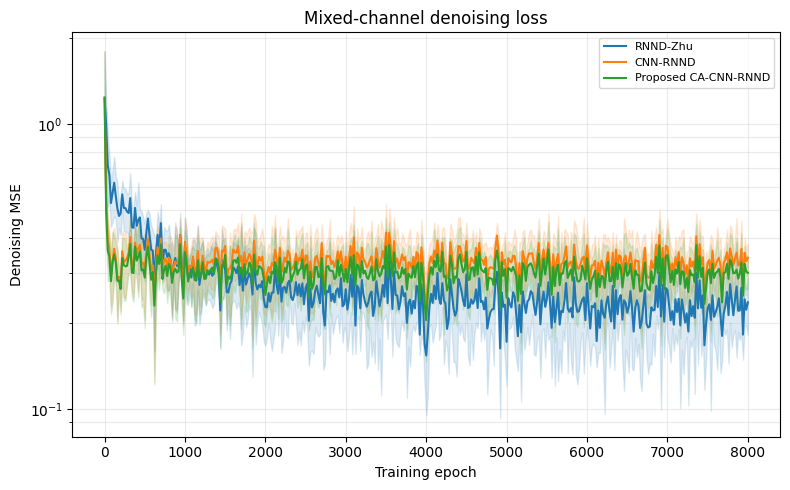

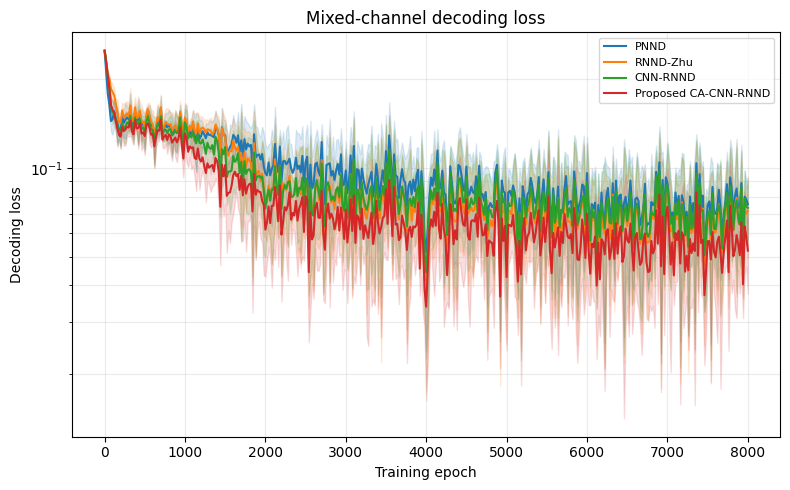

Training Loss Graph validation: PASSED
  ✓ Training_Denoising_Loss_MIXED.png
  ✓ Training_Decoding_Loss_MIXED.png


In [19]:

# Cell 17 — Training Loss Graphs (Mixed-channel, mean ± std over repeats)

TRAIN_DISPLAY = {
    "PNND": "PNND",
    "RNND_Zhu": "RNND-Zhu",
    "CNN_RNND": "CNN-RNND",
    "Proposed_CA_CNN_RNND": "Proposed CA-CNN-RNND",
}

def load_mixed_training_histories():
    frames = []

    for method in NEURAL_METHODS:
        pattern = f"repeat*_MIXED_{method}.csv"

        for path in sorted(
            (OUT / "histories").glob(pattern)
        ):
            h = pd.read_csv(path)

            if "repeat" not in h.columns:
                raise ValueError(
                    f"Missing 'repeat' column in {path}"
                )

            frames.append(h)

    if not frames:
        raise RuntimeError(
            "No MIXED training histories were found. "
            "Run the main experiment cell first."
        )

    return pd.concat(
        frames,
        ignore_index=True,
    )

mixed_history_df = load_mixed_training_histories()

# Downsample only for visualization. Raw histories remain unchanged.
plot_stride = max(
    1,
    int(cfg.max_epochs // 400)
)

plot_history = mixed_history_df[
    (mixed_history_df["epoch"] == 1)
    | (mixed_history_df["epoch"] % plot_stride == 0)
    | (mixed_history_df["epoch"] == cfg.max_epochs)
].copy()

# ---------------------------------------------------------
# Figure A — Denoising Loss vs. Training Epoch
# ---------------------------------------------------------
denoise_methods = [
    m for m in [
        "RNND_Zhu",
        "CNN_RNND",
        "Proposed_CA_CNN_RNND",
    ]
    if m in NEURAL_METHODS
]

plt.figure(figsize=(8, 5))

for method in denoise_methods:
    g = (
        plot_history[
            plot_history["method"] == method
        ]
        .groupby("epoch", as_index=False)
        .agg(
            mean_loss=("denoise_loss", "mean"),
            std_loss=("denoise_loss", "std"),
        )
    )

    g["std_loss"] = g["std_loss"].fillna(0.0)

    line = plt.plot(
        g["epoch"],
        g["mean_loss"],
        label=TRAIN_DISPLAY.get(method, method),
    )[0]

    plt.fill_between(
        g["epoch"],
        np.maximum(
            g["mean_loss"] - g["std_loss"],
            1e-12,
        ),
        g["mean_loss"] + g["std_loss"],
        alpha=0.15,
        color=line.get_color(),
    )

plt.yscale("log")
plt.xlabel("Training epoch")
plt.ylabel("Denoising MSE")
plt.title("Mixed-channel denoising loss")
plt.grid(True, which="both", alpha=0.25)
plt.legend(fontsize=8)
plt.tight_layout()

denoise_loss_path = (
    OUT / "figures" / "Training_Denoising_Loss_MIXED.png"
)

plt.savefig(
    denoise_loss_path,
    dpi=300,
)

plt.show()

# ---------------------------------------------------------
# Figure B — Decoding Loss vs. Training Epoch
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))

for method in NEURAL_METHODS:
    g = (
        plot_history[
            plot_history["method"] == method
        ]
        .groupby("epoch", as_index=False)
        .agg(
            mean_loss=("decode_loss", "mean"),
            std_loss=("decode_loss", "std"),
        )
    )

    g["std_loss"] = g["std_loss"].fillna(0.0)

    line = plt.plot(
        g["epoch"],
        g["mean_loss"],
        label=TRAIN_DISPLAY.get(method, method),
    )[0]

    plt.fill_between(
        g["epoch"],
        np.maximum(
            g["mean_loss"] - g["std_loss"],
            1e-12,
        ),
        g["mean_loss"] + g["std_loss"],
        alpha=0.15,
        color=line.get_color(),
    )

plt.yscale("log")
plt.xlabel("Training epoch")
plt.ylabel("Decoding loss")
plt.title("Mixed-channel decoding loss")
plt.grid(True, which="both", alpha=0.25)
plt.legend(fontsize=8)
plt.tight_layout()

decoding_loss_path = (
    OUT / "figures" / "Training_Decoding_Loss_MIXED.png"
)

plt.savefig(
    decoding_loss_path,
    dpi=300,
)

plt.show()

# Explicit verification so an incomplete ZIP cannot pass silently.
required_training_figures = [
    denoise_loss_path,
    decoding_loss_path,
]

missing = [
    str(p) for p in required_training_figures
    if not p.exists()
]

if missing:
    raise RuntimeError(
        "Training-loss figure generation failed. Missing:\n"
        + "\n".join(missing)
    )

print("Training Loss Graph validation: PASSED")
for p in required_training_figures:
    print("  ✓", p.name)


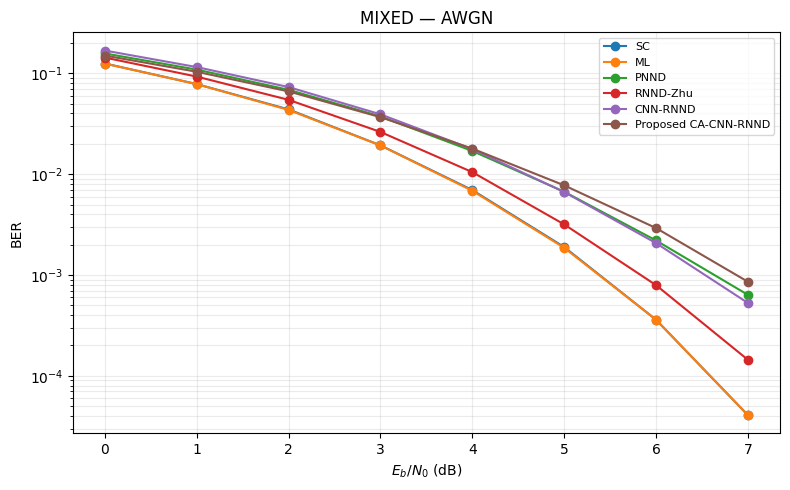

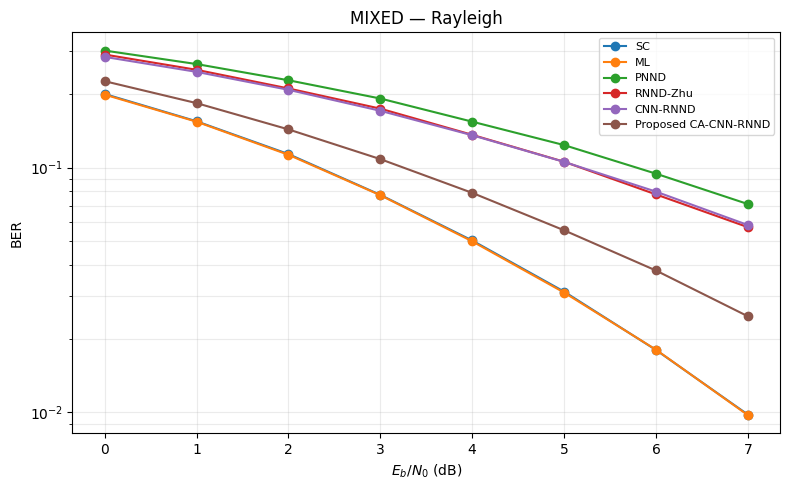

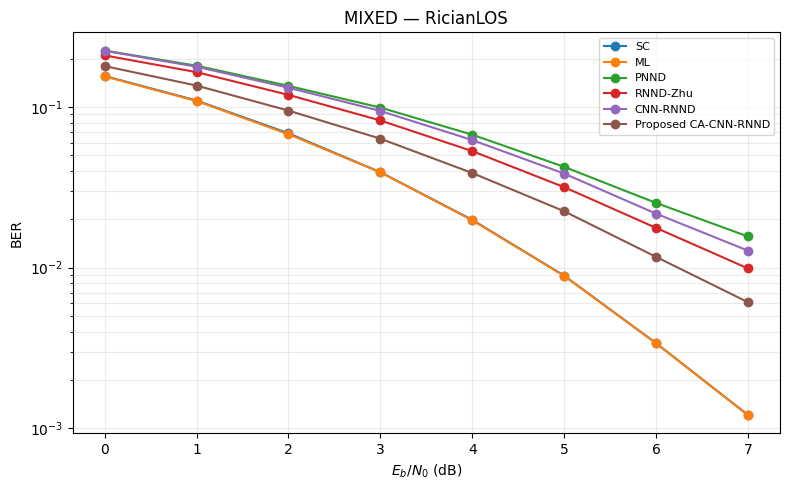

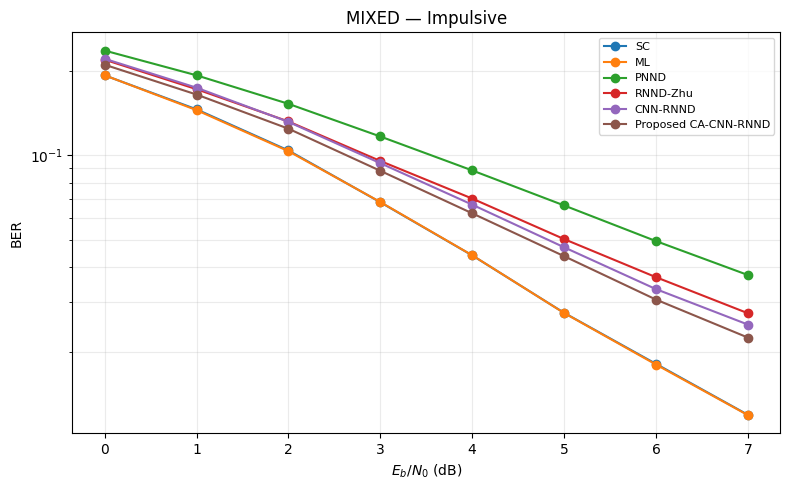

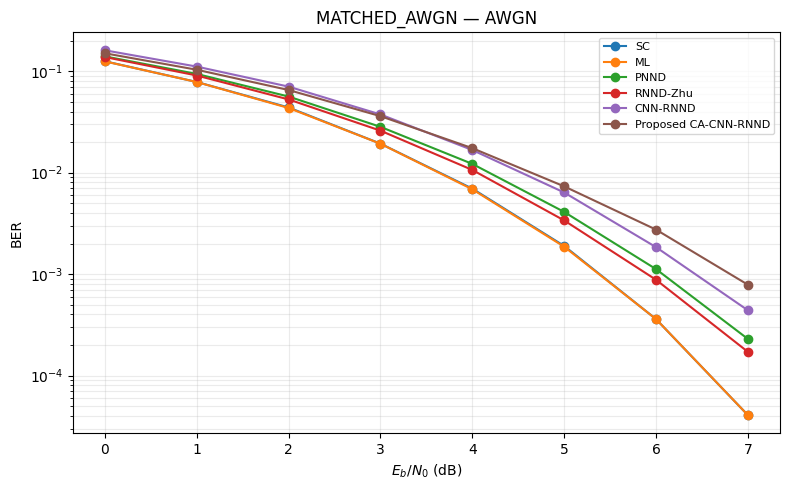

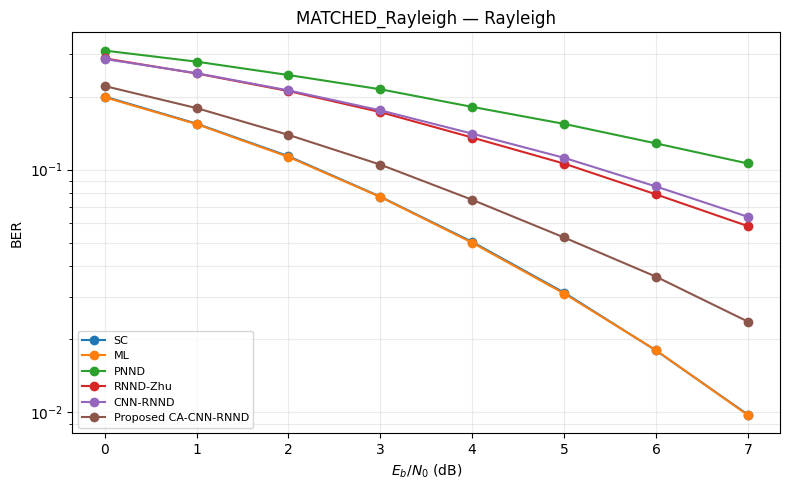

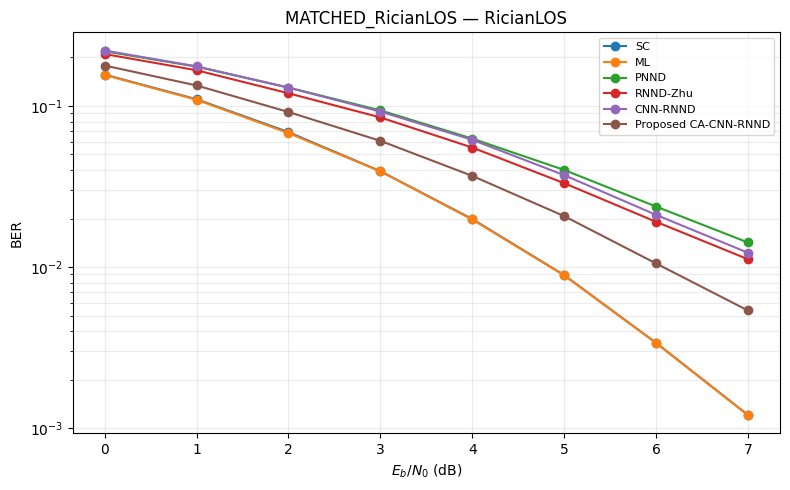

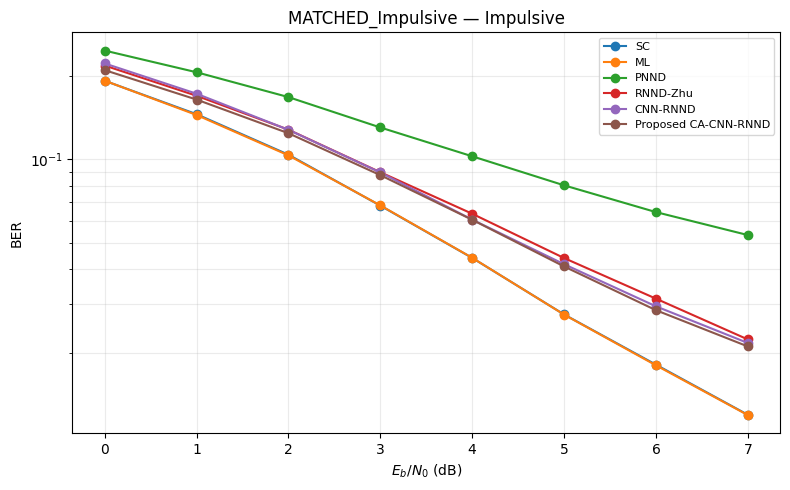

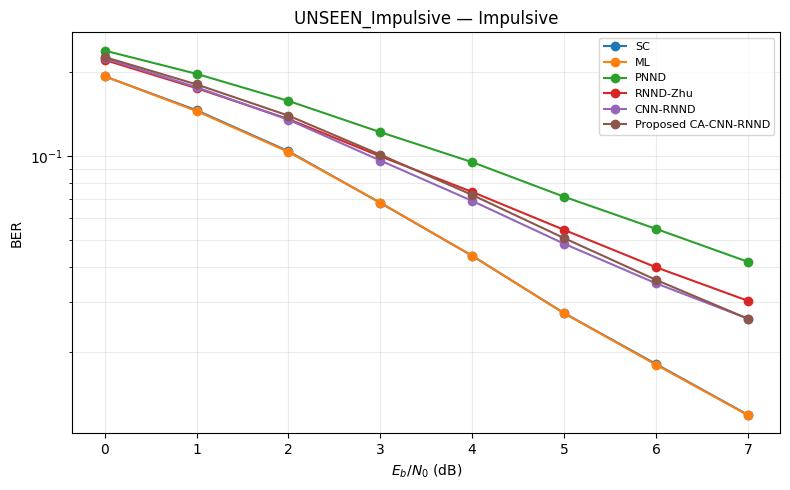

In [20]:

# Cell 17 — BER figures for every final experiment

DISPLAY = {
    "SC": "SC",
    "ML": "ML",
    "PNND": "PNND",
    "RNND_Zhu": "RNND-Zhu",
    "CNN_RNND": "CNN-RNND",
    "Proposed_CA_CNN_RNND": "Proposed CA-CNN-RNND",
}

def plot_ber_job(
    regime,
    job_tag,
    channel,
):
    d = summary_df[
        (summary_df["regime"] == regime)
        & (summary_df["job_tag"] == job_tag)
        & (summary_df["channel"] == channel)
    ]

    if len(d) == 0:
        return

    plt.figure(
        figsize=(8, 5)
    )

    for method in ALL_METHODS:
        x = d[
            d["method"] == method
        ].sort_values(
            "snr_db"
        )

        if len(x) == 0:
            continue

        plt.semilogy(
            x["snr_db"],
            np.clip(
                x["BER_mean"],
                1e-8,
                1.0,
            ),
            marker="o",
            label=DISPLAY.get(
                method,
                method,
            ),
        )

    plt.xlabel(
        r"$E_b/N_0$ (dB)"
    )
    plt.ylabel("BER")

    plt.title(
        f"{job_tag} — {channel}"
    )

    plt.grid(
        True,
        which="both",
        alpha=0.25,
    )

    plt.legend(
        fontsize=8
    )

    plt.tight_layout()

    plt.savefig(
        OUT
        / "figures"
        / f"BER_{job_tag}_{channel}.png",
        dpi=300,
    )

    plt.show()

for job in JOBS:
    for channel in job[
        "test_channels"
    ]:
        plot_ber_job(
            job["regime"],
            job["tag"],
            channel,
        )


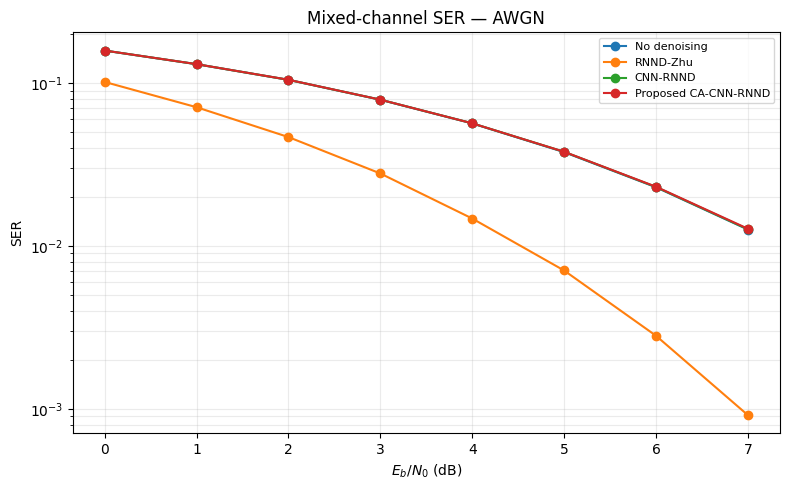

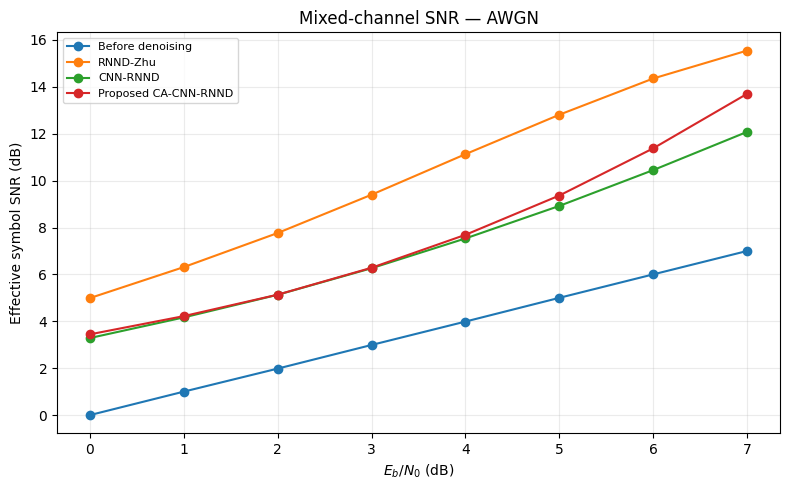

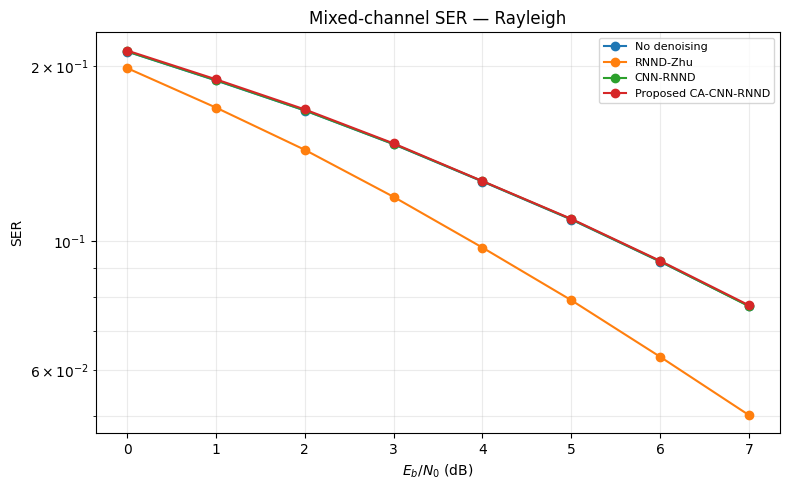

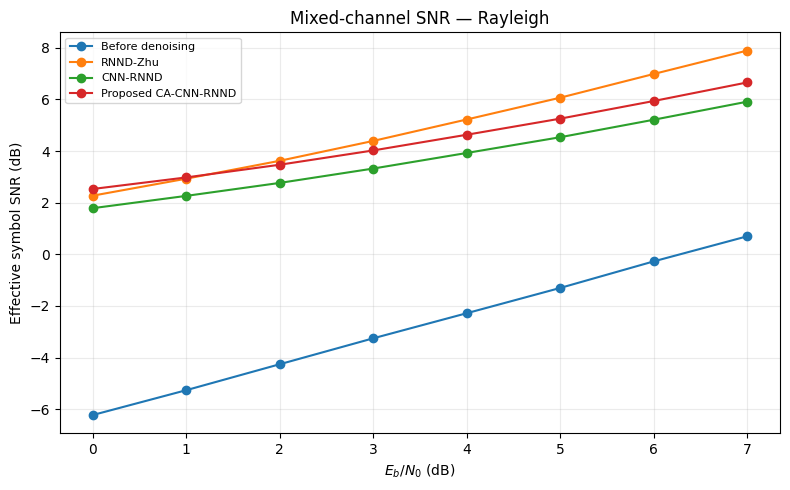

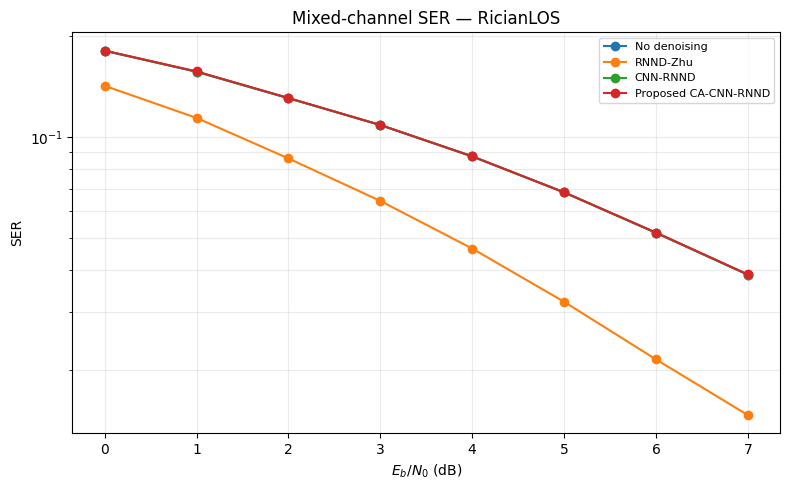

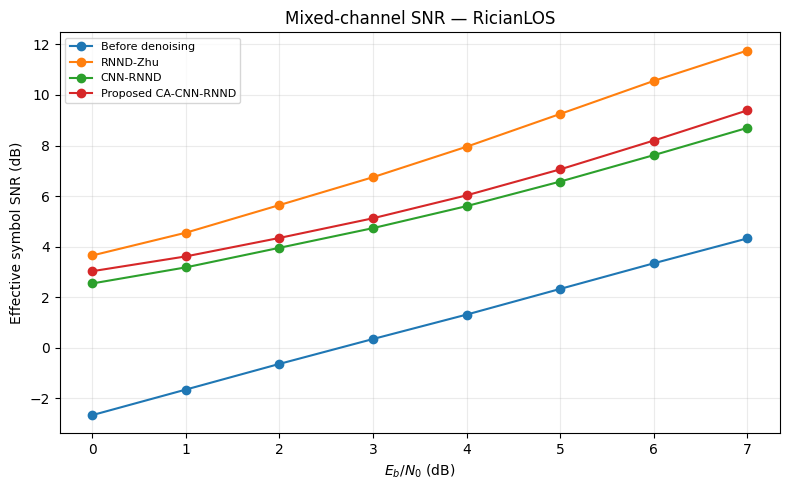

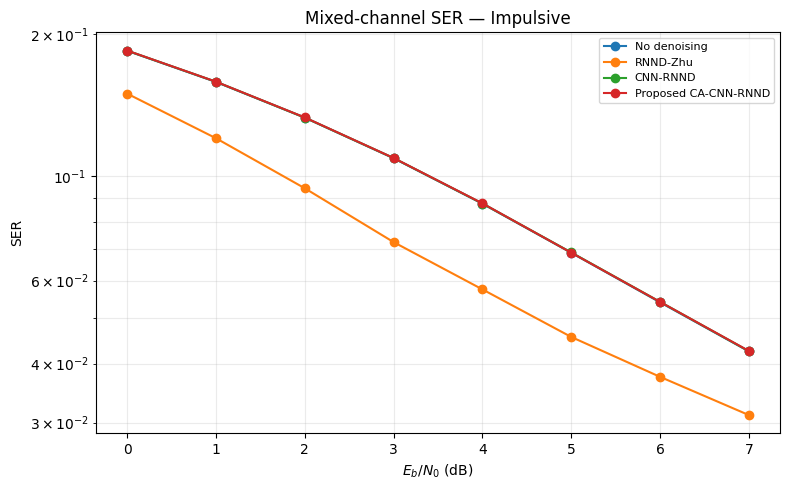

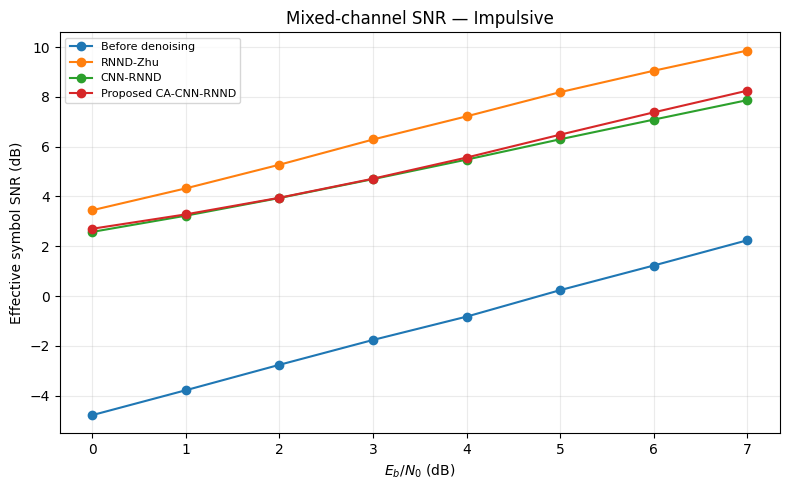

In [21]:

# Cell 18 — Mixed-channel SER and SNR figures

mixed_summary = summary_df[
    summary_df["regime"] == "mixed"
]

DENOISER_METHODS = [
    m for m in [
        "RNND_Zhu",
        "CNN_RNND",
        "Proposed_CA_CNN_RNND",
    ]
    if m in NEURAL_METHODS
]

for channel in cfg.channels:
    d = mixed_summary[
        mixed_summary["channel"]
        == channel
    ]

    # SER
    plt.figure(
        figsize=(8, 5)
    )

    reference_method = (
        DENOISER_METHODS[0]
        if DENOISER_METHODS
        else "PNND"
    )

    base = d[
        d["method"]
        == reference_method
    ].sort_values(
        "snr_db"
    )

    if len(base):
        plt.semilogy(
            base["snr_db"],
            np.clip(
                base[
                    "SER_no_denoise_mean"
                ],
                1e-8,
                1.0,
            ),
            marker="o",
            label="No denoising",
        )

    for method in DENOISER_METHODS:
        x = d[
            d["method"] == method
        ].sort_values(
            "snr_db"
        )

        if len(x):
            plt.semilogy(
                x["snr_db"],
                np.clip(
                    x[
                        "SER_after_mean"
                    ],
                    1e-8,
                    1.0,
                ),
                marker="o",
                label=DISPLAY.get(
                    method,
                    method,
                ),
            )

    plt.xlabel(
        r"$E_b/N_0$ (dB)"
    )
    plt.ylabel("SER")
    plt.title(
        f"Mixed-channel SER — {channel}"
    )
    plt.grid(
        True,
        which="both",
        alpha=0.25,
    )
    plt.legend(
        fontsize=8
    )
    plt.tight_layout()

    plt.savefig(
        OUT
        / "figures"
        / f"SER_MIXED_{channel}.png",
        dpi=300,
    )

    plt.show()

    # Effective SNR
    plt.figure(
        figsize=(8, 5)
    )

    if len(base):
        plt.plot(
            base["snr_db"],
            base[
                "SNR_before_dB_mean"
            ],
            marker="o",
            label="Before denoising",
        )

    for method in DENOISER_METHODS:
        x = d[
            d["method"] == method
        ].sort_values(
            "snr_db"
        )

        if len(x):
            plt.plot(
                x["snr_db"],
                x[
                    "SNR_after_dB_mean"
                ],
                marker="o",
                label=DISPLAY.get(
                    method,
                    method,
                ),
            )

    plt.xlabel(
        r"$E_b/N_0$ (dB)"
    )
    plt.ylabel(
        "Effective symbol SNR (dB)"
    )
    plt.title(
        f"Mixed-channel SNR — {channel}"
    )
    plt.grid(
        True,
        alpha=0.25,
    )
    plt.legend(
        fontsize=8
    )
    plt.tight_layout()

    plt.savefig(
        OUT
        / "figures"
        / f"SNR_MIXED_{channel}.png",
        dpi=300,
    )

    plt.show()


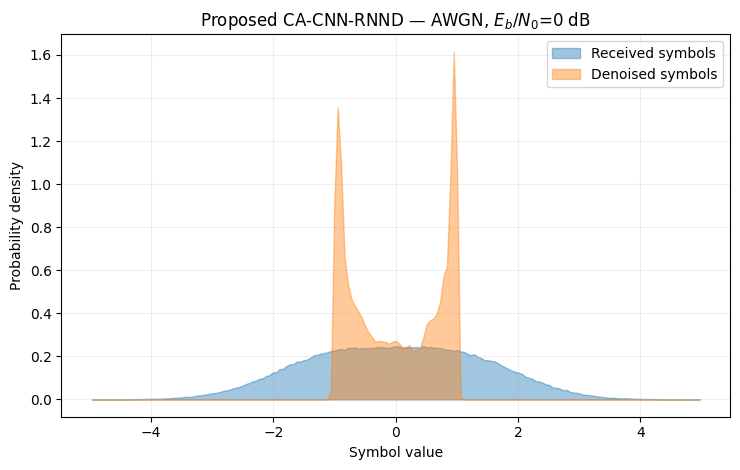

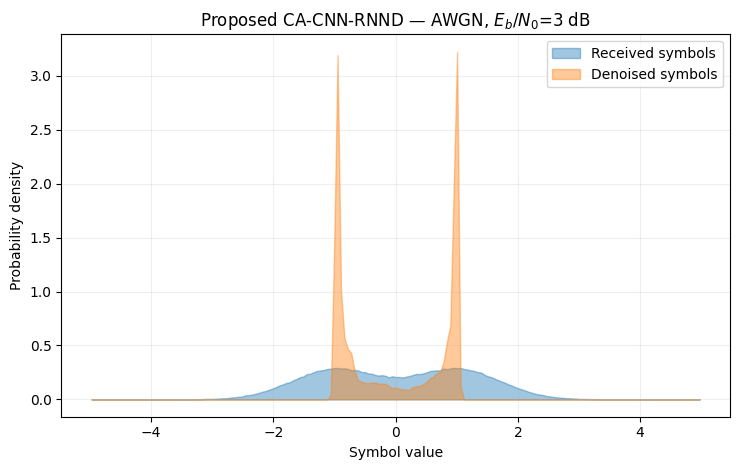

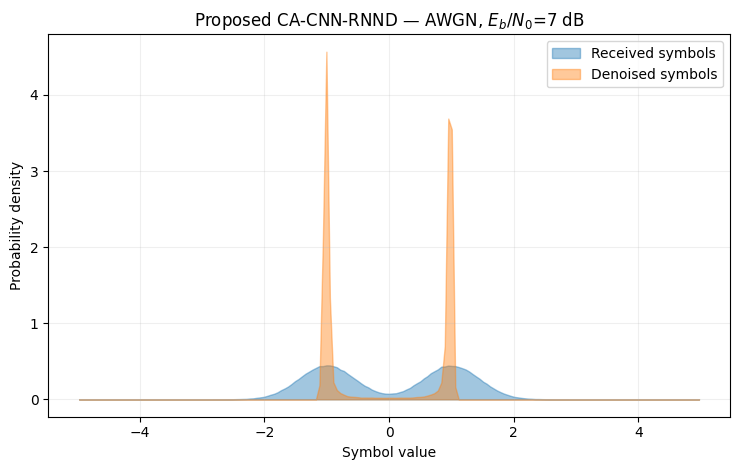

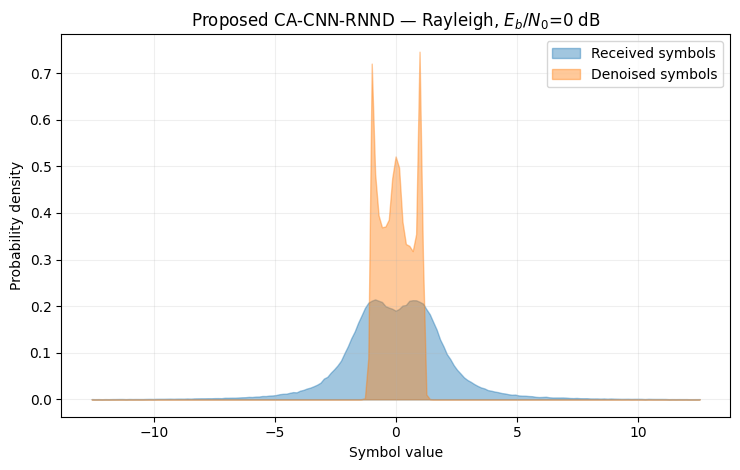

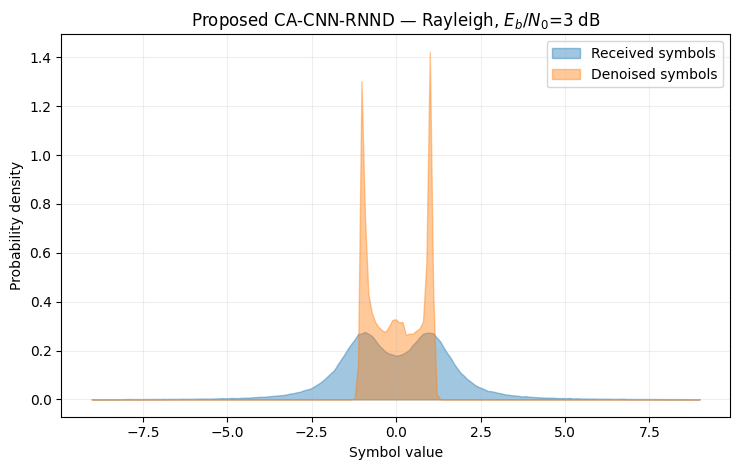

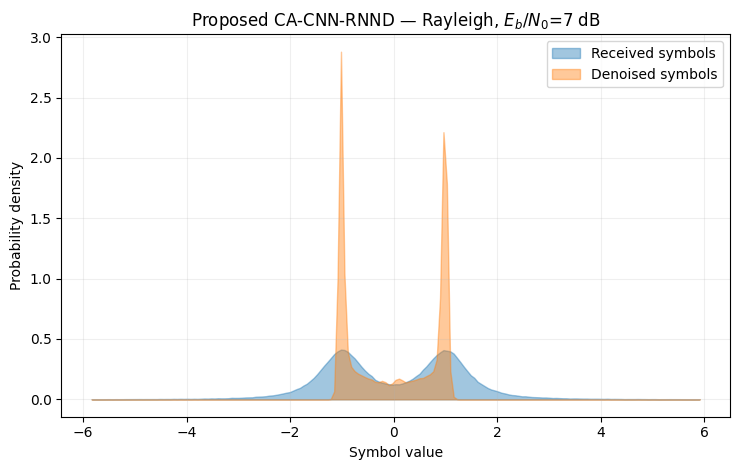

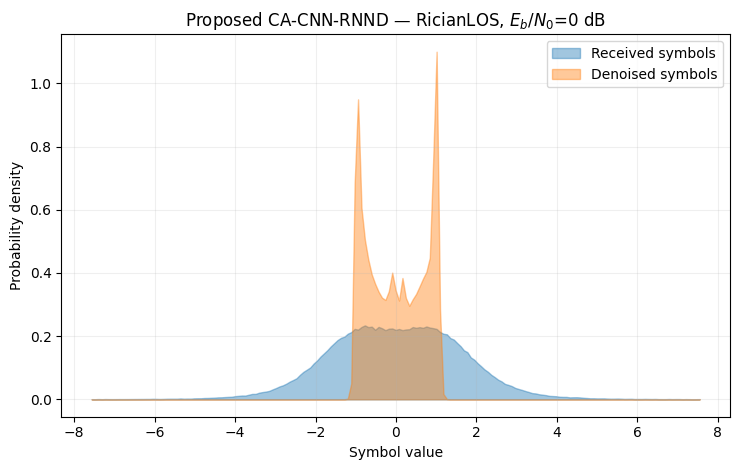

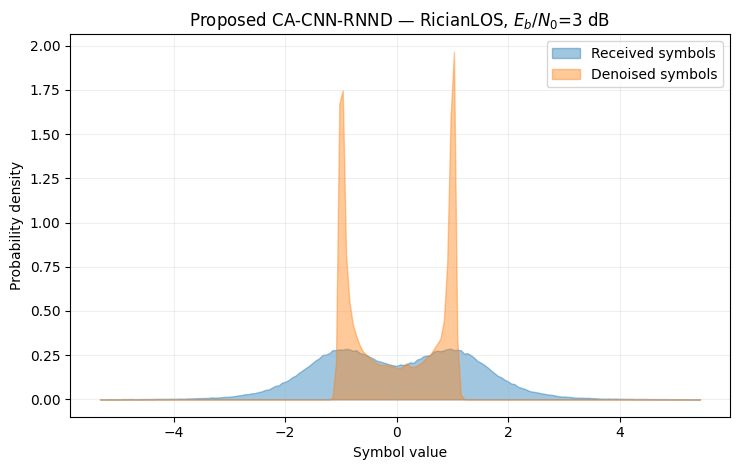

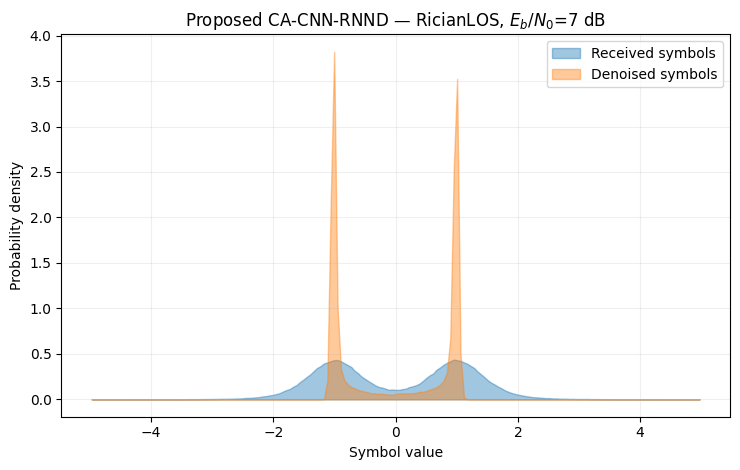

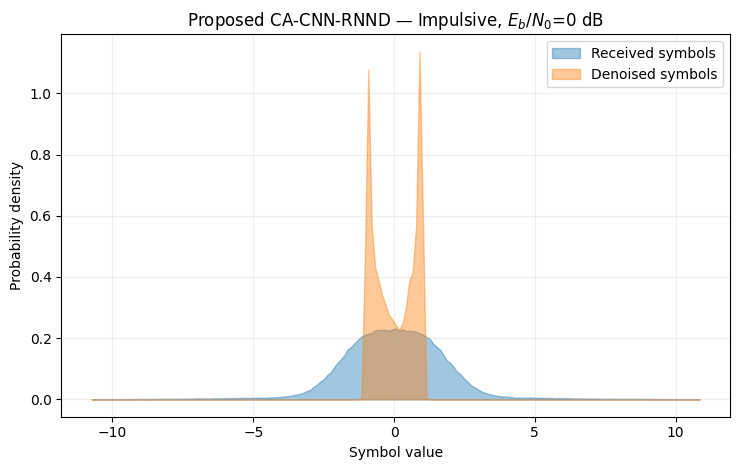

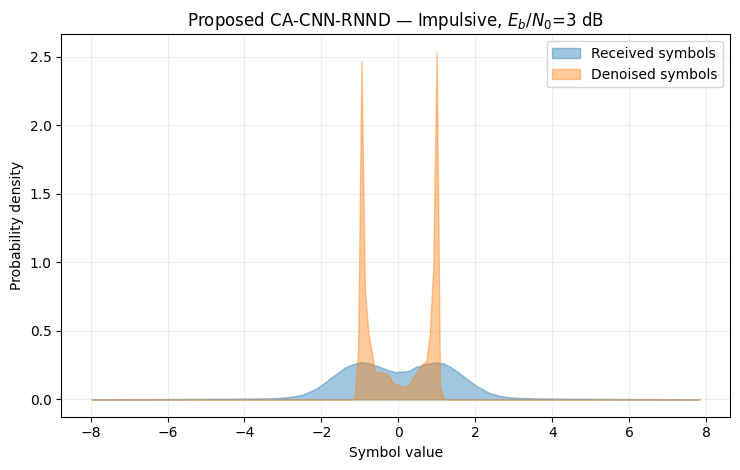

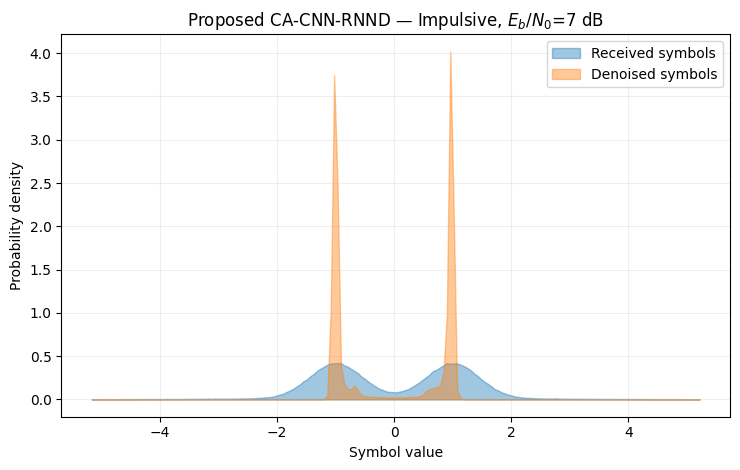

In [22]:

# Cell 19 — Proposed PDF figures from the last repeat, mixed-channel model

@torch.no_grad()
def save_pdf_figure(
    model,
    channel,
    snr_db,
    seed,
):
    model.eval()

    rng = np.random.default_rng(
        seed
    )

    idx = rng.integers(
        0,
        M,
        size=cfg.pdf_frames,
    )

    clean = S_TABLE[idx]

    chb = simulate_channel_numpy(
        clean,
        channel,
        snr_db,
        rng,
    )

    z = torch.tensor(
        chb["z"],
        dtype=torch.float32,
        device=DEVICE,
    )

    rel = torch.tensor(
        chb["reliability"],
        dtype=torch.float32,
        device=DEVICE,
    )

    snr_feat = torch.tensor(
        chb["snr_feature"],
        dtype=torch.float32,
        device=DEVICE,
    )

    out = model(
        z,
        rel,
        snr_feat,
    )

    received = (
        z.detach()
        .cpu()
        .numpy()
        .ravel()
    )

    denoised = (
        out["s_hat"]
        .detach()
        .cpu()
        .numpy()
        .ravel()
    )

    lo = min(
        -5.0,
        np.quantile(received, 0.001),
        np.quantile(denoised, 0.001),
    )

    hi = max(
        5.0,
        np.quantile(received, 0.999),
        np.quantile(denoised, 0.999),
    )

    bins = np.linspace(
        lo,
        hi,
        180,
    )

    h0, edges = np.histogram(
        received,
        bins=bins,
        density=True,
    )

    h1, _ = np.histogram(
        denoised,
        bins=bins,
        density=True,
    )

    centers = (
        0.5
        * (
            edges[:-1]
            + edges[1:]
        )
    )

    plt.figure(
        figsize=(7.5, 4.8)
    )

    # Requested convention:
    # blue = received
    # orange = denoised
    plt.fill_between(
        centers,
        h0,
        alpha=0.42,
        color="tab:blue",
        label="Received symbols",
    )

    plt.fill_between(
        centers,
        h1,
        alpha=0.42,
        color="tab:orange",
        label="Denoised symbols",
    )

    plt.xlabel(
        "Symbol value"
    )
    plt.ylabel(
        "Probability density"
    )

    plt.title(
        f"Proposed CA-CNN-RNND — "
        f"{channel}, "
        f"$E_b/N_0$={snr_db:g} dB"
    )

    plt.grid(
        True,
        alpha=0.2,
    )

    plt.legend()
    plt.tight_layout()

    plt.savefig(
        OUT
        / "figures"
        / f"PDF_Proposed_{channel}_{snr_db:g}dB.png",
        dpi=300,
    )

    plt.show()

    np.savez_compressed(
        OUT
        / "raw"
        / f"PDF_Proposed_{channel}_{snr_db:g}dB.npz",
        received=received,
        denoised=denoised,
    )

if "MIXED" in last_repeat_models:
    proposed_model = (
        last_repeat_models[
            "MIXED"
        ][
            "Proposed_CA_CNN_RNND"
        ]
    )

    for ch_i, channel in enumerate(
        cfg.channels
    ):
        for snr_db in cfg.pdf_snr_db:
            seed = (
                cfg.seed0
                + 9_000_000
                + ch_i * 1000
                + int(10 * snr_db)
            )

            save_pdf_figure(
                proposed_model,
                channel,
                snr_db,
                seed,
            )



## 12.2 V3.1 figure-output sanity check

This check confirms that the two Training Loss figures and the four Mixed-channel BER figures exist before the Results-section summary and ZIP packaging.


In [23]:

# Cell — V3.1 figure-output sanity check

expected_figure_files = [
    OUT / "figures" / "Training_Denoising_Loss_MIXED.png",
    OUT / "figures" / "Training_Decoding_Loss_MIXED.png",
]

for channel in cfg.channels:
    expected_figure_files.append(
        OUT / "figures" / f"BER_MIXED_{channel}.png"
    )

missing_expected = [
    str(p)
    for p in expected_figure_files
    if not p.exists()
]

if missing_expected:
    raise RuntimeError(
        "V3.1 figure-output sanity check failed. Missing:\n"
        + "\n".join(missing_expected)
    )

print("V3.1 figure-output sanity check: PASSED")
print("Verified figure files:", len(expected_figure_files))


V3.1 figure-output sanity check: PASSED
Verified figure files: 6


# 13. Automatic Results-section notes

In [24]:

# Cell 20 — Descriptive final ranking and manuscript notes

ranking_rows = []

for (
    regime,
    job_tag,
    method,
), g in raw_df.groupby(
    [
        "regime",
        "job_tag",
        "method",
    ]
):
    ber = np.asarray(
        g["BER"],
        dtype=float,
    )

    ranking_rows.append({
        "regime": regime,
        "job_tag": job_tag,
        "method": method,
        "mean_BER": float(
            np.mean(ber)
        ),
        "mean_log10_BER": float(
            np.mean(
                np.log10(
                    np.clip(
                        ber,
                        1e-8,
                        1.0,
                    )
                )
            )
        ),
    })

ranking_df = pd.DataFrame(
    ranking_rows
).sort_values(
    [
        "regime",
        "job_tag",
        "mean_log10_BER",
    ]
)

ranking_df.to_csv(
    OUT
    / "paper"
    / "descriptive_method_ranking.csv",
    index=False,
)

notes = []

for job in JOBS:
    tag = job["tag"]

    r = ranking_df[
        ranking_df["job_tag"] == tag
    ]

    proposed_row = r[
        r["method"]
        == "Proposed_CA_CNN_RNND"
    ]

    if len(proposed_row) == 0:
        continue

    proposed_ber = float(
        proposed_row[
            "mean_BER"
        ].iloc[0]
    )

    neural_baselines = r[
        r["method"].isin(
            [
                m
                for m in NEURAL_METHODS
                if m
                != "Proposed_CA_CNN_RNND"
            ]
        )
    ]

    if len(neural_baselines):
        best_base = (
            neural_baselines
            .sort_values(
                "mean_log10_BER"
            )
            .iloc[0]
        )

        base_ber = float(
            best_base["mean_BER"]
        )

        reduction = (
            (base_ber - proposed_ber)
            / max(base_ber, 1e-12)
        )

        notes.append(
            f"{tag}: Proposed mean BER={proposed_ber:.6e}; "
            f"best neural baseline={best_base['method']} "
            f"with mean BER={base_ber:.6e}; "
            f"relative BER reduction={100*reduction:.2f}%."
        )

notes_text = "\n".join(
    notes
)

print(notes_text)

(
    OUT
    / "paper"
    / "RESULTS_SECTION_NOTES.txt"
).write_text(
    notes_text,
    encoding="utf-8",
)


MIXED: Proposed mean BER=7.950919e-02; best neural baseline=RNND_Zhu with mean BER=9.770670e-02; relative BER reduction=18.62%.
MATCHED_AWGN: Proposed mean BER=4.785626e-02; best neural baseline=RNND_Zhu with mean BER=4.025511e-02; relative BER reduction=-18.88%.
MATCHED_Rayleigh: Proposed mean BER=1.039688e-01; best neural baseline=RNND_Zhu with mean BER=1.623253e-01; relative BER reduction=35.95%.
MATCHED_RicianLOS: Proposed mean BER=6.720022e-02; best neural baseline=RNND_Zhu with mean BER=8.740590e-02; relative BER reduction=23.12%.
MATCHED_Impulsive: Proposed mean BER=9.229533e-02; best neural baseline=CNN_RNND with mean BER=9.582876e-02; relative BER reduction=3.69%.
UNSEEN_Impulsive: Proposed mean BER=1.040970e-01; best neural baseline=CNN_RNND with mean BER=1.012367e-01; relative BER reduction=-2.83%.


820

# 14. Final manifest and ZIP

In [25]:

# Cell 21 — Save manifest + complete run ZIP

files = sorted(
    str(
        p.relative_to(OUT)
    )
    for p in OUT.rglob("*")
    if p.is_file()
)

manifest = {
    "run_id": RUN_ID,
    "created": datetime.now().isoformat(),
    "mode": MODE,
    "include_rnnd_zhu": INCLUDE_RNND_ZHU,
    "methods": ALL_METHODS,
    "jobs": JOBS,
    "repeats": cfg.repeats,
    "test_snr_db": list(cfg.test_snr_db),
    "files": files,
}

with open(
    OUT / "manifest.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        manifest,
        f,
        indent=2,
        default=list,
    )

zip_path = shutil.make_archive(
    str(OUT),
    "zip",
    root_dir=OUT,
)

print("Completed run:", RUN_ID)
print("Result directory:", OUT.resolve())
print("ZIP archive:", Path(zip_path).resolve())
print("Saved files:", len(files))


Completed run: polar_final_v3_1_final_locked_paper_20260817_133553_e91fa9ed06
Result directory: /home/bt/Documents/Po/polar1/polar_final_journal_v3_1_final_locked_results/polar_final_v3_1_final_locked_paper_20260817_133553_e91fa9ed06
ZIP archive: /home/bt/Documents/Po/polar1/polar_final_journal_v3_1_final_locked_results/polar_final_v3_1_final_locked_paper_20260817_133553_e91fa9ed06.zip
Saved files: 298



# Files to send back for Results-section analysis

After `MODE="paper"` finishes, the most important files are:

- `all_test_results_raw.csv`
- `results_mean_std_by_snr.csv`
- `selected_checkpoint_summary.csv`
- `statistical_significance.csv`
- `paper_BER_table.csv`
- `paper_ablation_table.csv`
- `paper_matched_channel_table.csv`
- `paper_unseen_channel_table.csv`
- `paper_computational_cost.csv`
- `RESULTS_SECTION_NOTES.txt`

Do not report the smoke-test values in the manuscript.
